In [2]:
import os
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from astral import LocationInfo
from astral.sun import sun
import pytz

In [3]:
# Disable osmnx HTTP cache — no notebooks/cache/ directory created.
# Graph is persisted to data/processed/ so subsequent runs skip the download.
# Delete sd_walk_graph.graphml manually to force a re-download.
ox.settings.use_cache = False

_graphml_path = "../data/processed/sd_walk_graph.graphml"

if os.path.exists(_graphml_path):
    G = ox.load_graphml(_graphml_path)
else:
    G = ox.graph_from_place("San Diego, CA, USA", network_type="walk")
    ox.save_graphml(G, _graphml_path)

edges = ox.graph_to_gdfs(G, nodes=False)
print(f"CRS:         {edges.crs}")
print(f"Total edges: {len(edges):,}")
print(f"Bounds:      {edges.total_bounds}")


CRS:         epsg:4326
Total edges: 684,012
Bounds:      [-117.324036    32.5339564 -116.9075593   33.1144246]


In [4]:
import pandas as pd

def _first(v):
    return v[0] if isinstance(v, list) else v

hw = edges["highway"].apply(_first)
total = len(edges)

# ── Highway types that are physically inaccessible to pedestrians ──────────
DROP_HIGHWAY = {
    "trunk",          # expressway — no pedestrian access
    "trunk_link",     # expressway on/off ramp
    "busway",         # bus-only lane (e.g. MTS Rapid Busway)
    "bridleway",      # horses and bikes only — pedestrians excluded
    "bus_stop",       # transit infrastructure, not a routable edge
    "emergency_bay",  # emergency vehicles only
}

# ── Service road subtypes that are not valid pedestrian routes ─────────────
DROP_SERVICE = {
    "parking_aisle",    # internal parking lot lane
    "parking",          # parking area surface
    "driveway",         # private driveway — not a through-route
    "emergency_access", # gated, inaccessible
    "slipway",          # boat ramp
    "yard",             # private yard
}

svc_sub = edges["service"].apply(_first) if "service" in edges.columns else pd.Series("", index=edges.index)
is_service   = hw == "service"
is_drop_hw   = hw.isin(DROP_HIGHWAY)
is_drop_svc  = is_service & svc_sub.isin(DROP_SERVICE)
drop_mask    = is_drop_hw | is_drop_svc
keep_mask    = ~drop_mask

# ── Print summary ──────────────────────────────────────────────────────────
print(f"Total edges in walk graph : {total:,}")
print(f"Dropped                   : {drop_mask.sum():,}  ({100*drop_mask.sum()/total:.1f}%)")
print(f"Kept                      : {keep_mask.sum():,}  ({100*keep_mask.sum()/total:.1f}%)")

print("\n── Dropped: non-pedestrian highway types (" + str(is_drop_hw.sum()) + " edges, " + f"{100*is_drop_hw.sum()/total:.2f}%) ──")
for ht in ["trunk", "trunk_link", "busway", "bridleway", "bus_stop", "emergency_bay"]:
    n = (hw == ht).sum()
    if n:
        print(f"  {ht:<20} {n:6,}  ({100*n/total:.3f}%)")

print("\n── Dropped: service subtypes (" + str(is_drop_svc.sum()) + " edges, " + f"{100*is_drop_svc.sum()/total:.1f}%) ──")
for st in ["parking_aisle", "driveway", "emergency_access", "parking", "slipway", "yard"]:
    n = (is_service & (svc_sub == st)).sum()
    if n:
        print(f"  service/{st:<18} {n:6,}  ({100*n/total:.3f}%)")

print("\n── Kept service subtypes ──────────────────────────────────────────────")
for st, n in svc_sub[is_service & keep_mask].value_counts().items():
    label = f"service/{st}" if st else "service/<untyped>"
    print(f"  {label:<28} {n:6,}  ({100*n/total:.3f}%)")

print("\n── Kept highway types ─────────────────────────────────────────────────")
kept_hw = hw[keep_mask].value_counts()
for ht, n in kept_hw.items():
    print(f"  {ht:<20} {n:6,}  ({100*n/keep_mask.sum():.1f}% of kept)")


Total edges in walk graph : 684,012
Dropped                   : 96,637  (14.1%)
Kept                      : 587,375  (85.9%)

── Dropped: non-pedestrian highway types (2541 edges, 0.37%) ──
  trunk                   794  (0.116%)
  trunk_link              196  (0.029%)
  busway                  327  (0.048%)
  bridleway             1,218  (0.178%)
  bus_stop                  4  (0.001%)
  emergency_bay             2  (0.000%)

── Dropped: service subtypes (94096 edges, 13.8%) ──
  service/parking_aisle      68,025  (9.945%)
  service/driveway           25,242  (3.690%)
  service/emergency_access      802  (0.117%)
  service/parking                19  (0.003%)
  service/slipway                 6  (0.001%)
  service/yard                    2  (0.000%)

── Kept service subtypes ──────────────────────────────────────────────
  service/alley                13,243  (1.936%)
  service/drive-through         1,907  (0.279%)
  service/access                    4  (0.001%)
  service/car_wash     

## Walk Graph — Highway Type Filter

OSMnx's `network_type="walk"` errs on the side of inclusion: it pulls in any road a pedestrian *could* physically reach, including bus-only lanes, expressways, and private driveways. Before scoring, we drop the edges that are genuinely inaccessible or non-routable for pedestrians.

---

### What gets dropped — 96,637 edges (14.1%)

**Non-pedestrian highway types — 2,541 edges (0.4%)**

| Type | Count | % of total | Reason |
|---|---|---|---|
| `bridleway` | 1,218 | 0.18% | Horses and bikes only — pedestrians excluded by law |
| `trunk` | 794 | 0.12% | Expressway — no pedestrian access |
| `busway` | 327 | 0.05% | Bus-only lane (e.g. MTS Rapid Busway in Mission Valley) |
| `trunk_link` | 196 | 0.03% | Expressway on/off ramps |
| `bus_stop` | 4 | <0.01% | Transit infrastructure node, not a routable edge |
| `emergency_bay` | 2 | <0.01% | Emergency vehicles only |

**Non-routable `service` subtypes — 94,096 edges (13.8%)**

The majority of dropped edges are `service` roads with subtypes that confirm they are not valid pedestrian through-routes:

| Subtype | Count | % of total | Reason |
|---|---|---|---|
| `parking_aisle` | 68,025 | 9.9% | Internal parking lot lanes — no through-routing |
| `driveway` | 25,242 | 3.7% | Private driveways — not public routes |
| `emergency_access` | 802 | 0.1% | Gated, inaccessible to the public |
| `parking` | 19 | <0.01% | Parking surface area |
| `slipway` | 6 | <0.01% | Boat ramp |
| `yard` | 2 | <0.01% | Private yard |

> `parking_aisle` alone accounts for **70.4% of all dropped edges** and **9.9% of the entire graph**.

---

### What gets kept — 587,375 edges (85.9%)

**`service` edges kept:** 165,498 edges across four valid subtypes plus ~150,000 untyped edges (no OSM subtype recorded — kept by default since OSMnx already validated them as part of the walk network):

| Subtype | Count | Notes |
|---|---|---|
| `<untyped>` | ~150,342 | No subtype recorded — includes shared access roads and alleys |
| `alley` | 13,243 | Valid pedestrian shortcut between blocks |
| `drive-through` | 1,907 | Commercial — lit, accessible |
| `access` | 4 | Generic access road |
| `car_wash` | 2 | Commercial |

**All other kept types:** `footway` (29.6%), `residential` (20.6%), `tertiary` (7.6%), `secondary` (4.0%), `path` (3.3%), `primary` (3.2%), `unclassified` (0.9%), `track` (0.7%), `pedestrian` (0.6%), `steps` (0.6%), `living_street` (0.3%), road links and `corridor`/`elevator`.

---

### Why this matters for scoring

Before this filter, `service` roads made up **38%** of the graph and dragged headline coverage numbers for `light_score` down to 28.8% overall. On the **pedestrian-relevant** edges kept here, real streetlight coverage sits at **38–45%** for every road type a walker would actually use (`footway`, `residential`, `primary`, `secondary`, `tertiary`).


In [5]:
edges = edges[keep_mask].copy()

In [6]:
# load in the crime, walkability, and light data
crime_gdf = gpd.read_file("../data/processed/crime_final_gdf.gpkg")
walkability_gdf = gpd.read_file("../data/processed/walkability_final_gdf.gpkg")
light_gdf = gpd.read_file("../data/processed/streetlights/streetlights_processed.geojson")

display(crime_gdf.head())
display(walkability_gdf.head())
display(light_gdf.head())


crime_gdf.describe()

,INCIDENT_NUM,DATE_TIME,DAY_OF_WEEK,ADDRESS_ROAD_PRIMARY,CALL_TYPE,DISPOSITION,PRIORITY,HOUR,geometry
0,E26040027846,2026-04-20 10:48:53,2.0,EL CAJON,415V,R,1.0,10,POINT (-117.06696 32.76148)
1,E26040027876,2026-04-20 11:07:54,2.0,C,242,R,1.0,11,POINT (-117.16002 32.71684)
2,E26040027882,2026-04-20 11:10:22,2.0,HOTEL CIRCLE SOUTH,415V,R,1.0,11,POINT (-117.17811 32.7589)
3,E26040027891,2026-04-20 11:15:24,2.0,LANDIS,242R,R,2.0,11,POINT (-117.12218 32.74549)
4,E26040028068,2026-04-20 13:20:46,2.0,AIR,415V,O,1.0,13,POINT (-117.09512 32.71952)


,GEOID,CBSA,CBSA_Name,TotPop,NatWalkInd,geometry
0,060730027122,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1653,13.500000,"POLYGON ((-117.08306 32.72588, -117.0828 32.72..."
1,060730186012,41740.0,"San Diego-Chula Vista-Carlsbad, CA",3958,5.333333,"POLYGON ((-117.35296 33.22489, -117.35294 33.2..."
2,060730186093,41740.0,"San Diego-Chula Vista-Carlsbad, CA",2376,13.000000,"POLYGON ((-117.31819 33.25084, -117.31819 33.2..."
3,060730194063,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1485,6.500000,"POLYGON ((-117.2737 33.19762, -117.27367 33.19..."
4,060730195032,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1079,16.333333,"POLYGON ((-117.24344 33.20156, -117.24329 33.2..."


,sap_obj_nr,status,mapng_stat_cd,drawing_date,dup_sapobjnr_flag,data_quality_flag,geometry
0,IF?0100000000000243406,A,AB,None,0,ok,POINT (-117.23655 32.76638)
1,IF?0100000000000239557,A,AB,None,0,ok,POINT (-117.1539 32.72578)
2,IF?0100000000000243586,A,AB,None,0,ok,POINT (-117.23572 32.76619)
3,IF?0100000000000238417,A,AB,None,0,ok,POINT (-117.1091 32.71928)
4,IF?0100000000000238529,A,AB,None,0,ok,POINT (-117.10915 32.71963)


,DATE_TIME,DAY_OF_WEEK,PRIORITY,HOUR
count,46169,46169.000000,46169.000000,46169.000000
mean,2024-12-08 20:14:28.269000,3.994802,1.148455,12.955923
min,2024-01-01 00:08:14,1.000000,0.000000,0.000000
25%,2024-05-25 21:27:47,2.000000,1.000000,9.000000
50%,2024-10-11 13:36:39,4.000000,1.000000,14.000000
75%,2025-06-20 12:04:54,6.000000,1.000000,18.000000
max,2026-04-23 21:35:02,7.000000,9.000000,23.000000
std,NaN,2.024043,1.129833,6.459321


## Crime Scoring — Score Reference & Reasoning

Each crime row gets one `severity_score` based on its call type. The score bakes in two things together: **how serious is this crime** (FBI UCR hierarchy) and **how directly does it affect someone walking nearby** (pedestrian exposure). Both inform the single number — high seriousness + high exposure = 3.0; low seriousness + low exposure = 0.4.

**Score range:** 0.4 (lowest pedestrian risk) → 3.0 (maximum pedestrian danger)

---

### Score 3.0 — Maximum danger: direct lethal or predatory threat to a person on foot

**HOMICIDE**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `187` | Murder | Highest-severity crime possible. A confirmed murder nearby signals a lethal threat that has already materialized. Direct exposure — anyone in the vicinity is at risk from an offender who has demonstrated willingness to kill. |
| `187-SUSP` | Murder suspect at scene | Suspect still present at or near a murder scene. Active, armed, already proven lethal. Maximum score regardless of time of day. |

**KIDNAPPING**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `207` | Kidnapping in progress | Active predatory abduction of a person. The offender is physically targeting individuals on foot or nearby. Highest FBI tier, maximum direct pedestrian exposure. |
| `207R` | Kidnapping report | Predatory offender confirmed operating in this corridor. A pedestrian walking the same route faces demonstrated risk of targeted attack. |

**ASSAULT WITH DEADLY WEAPON**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `245` | ADW in progress | Active weapon assault on a person. Attacker is armed and already using a weapon — immediate lethal threat to any pedestrian in range. |
| `245-SUSP` | ADW suspect at scene | Armed suspect confirmed at scene of a weapon assault. |
| `245DV` | ADW domestic violence | Weapon assault in a domestic violence context — active scene, attacker potentially still present. |
| `245R` | ADW report | Pattern signal: a weapon assault happened in this corridor. Demonstrates the area has seen lethal-force incidents. |
| `417` | Threatening with weapon | Person actively threatening others with a weapon. Immediate danger to any pedestrian nearby. |
| `417R` | Threatening with weapon report | Recent weapon threat in this corridor — attacker not yet apprehended. |

**ROBBERY**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `211` | Robbery in progress | Active robbery — offender is using force or threat against victims right now. Direct, targeted threat to pedestrians. |
| `211-SUSP` | Robbery suspect at scene | Suspect still on scene of an active robbery. Extreme pedestrian exposure. |
| `211R` | Robbery report | Confirmed robbery pattern in this corridor. Pedestrians are the target. |
| `211C` | Robbery caser | Offender observed casing for robbery — pre-crime indicator of active targeting in this area. |

---

### Score 2.8 — High danger: targeted vehicle theft with potential violence

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `215` | Car jacking in progress | Active car jacking — attacker confronted the victim in a vehicle. High violence potential, pedestrians nearby are in the threat zone. |
| `215R` | Car jacking report | Confirmed carjacking in this corridor. Lower than in-progress but still a high pedestrian risk signal. |

---

### Score 2.4 — Significant danger: lethal force deployed or threatened at area level

**FIREARMS DISCHARGE**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `246` | Firing at occupied house/vehicle | Shots fired at an occupied structure or vehicle — bullets are moving through the public space a pedestrian would occupy. |
| `246R` | Firing at occupied house/vehicle report | Confirmed shooting incident in this corridor. Active shooter pattern in the area. |
| `247` | Firing at unoccupied vehicle | Shots fired at property — less immediately lethal than `246` but live rounds were discharged in the area. |
| `247R` | Firing at unoccupied vehicle report | Pattern of live-fire incidents in this corridor. |
| `11-6` | Discharging firearms | Shots fired in the area — any pedestrian in the corridor is in the trajectory zone. |
| `11-6SPT` | ShotSpotter activation | Acoustic gunshot detection confirmation. Shots fired, precise location confirmed by sensor. |

**BOMB / EXPLOSION**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `EXPLO` | Explosion | An explosion has occurred — immediate danger to anyone in the area. |
| `ALERT4` | Bomb/hijack threat | Confirmed credible bomb or hijack threat. Law enforcement response, area cordoned. |
| `BOMB` | Bomb threat | Active bomb threat at a location in this corridor. |
| `BOMB-S` | Bomb threat (school) | School-located bomb threat — area likely under evacuation, elevated pedestrian/civilian exposure. |

---

### Score 2.0 — Moderate-high danger: direct physical assault or credible personal threats

**BATTERY**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `242` | Battery in progress | Physical assault actively occurring. The attacker is already using force against a person. |
| `242R` | Battery report | Confirmed physical assault in this corridor. Pattern signal for pedestrian risk. |

**THREATS / STALKING**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `422` | Criminal threats | Explicit criminal threat against a person — escalation to violence is credible. |
| `422R` | Criminal threats report | Documented criminal threat in this area. |
| `136` | Intimidation of witness | Witness intimidation — organized threat activity operating in this corridor. |
| `646` | Stalking | Active stalking — targeted predatory behavior against a specific person in this area. |
| `646R` | Stalking report | Documented stalking pattern in this corridor. |
| `653M` | Threatening phone call report | Credible threat made by phone — attacker has identified a target in this area. |
| `415W` | Disturbing peace with unconcealed weapon | Person carrying a weapon visibly in public — immediate intimidation threat to pedestrians nearby. |

---

### Score 1.6 — Moderate danger: escalating situation or violent disturbance

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `415V` | Disturbing peace with violence | Active violent disturbance — physical altercation in a public area, pedestrians nearby are at risk. |
| `415DV` | Domestic violence occurring now | Active domestic violence incident — volatile, often escalates, anyone nearby is in the danger zone. |
| `5150V` | Mental case — violent or urgent | Violent psychiatric crisis. Person is in active distress and has been violent or is imminently likely to be. |
| `FP` | Foot pursuit | Police foot pursuit underway — suspect is fleeing through pedestrian areas. |
| `ESCAPE` | Escape / escapee | A person has escaped from custody. Apprehension in progress, may pass through pedestrian corridors. |

---

### Score 1.2 — Lower-moderate: property crime with some pedestrian exposure

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `451` | Arson in progress | Active fire-setting — immediate hazard to anyone in the area. |
| `451R` | Arson report | Confirmed arson in this corridor — fire hazard and pattern indicator. |

---

### Score 0.8 — Low-moderate: opportunistic entry crime

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `459HP` | Burglary hot prowl | Burglar entered an occupied residence — high aggression indicator, offender willing to confront occupants. Moderate pedestrian exposure. |

---

### Score 0.6 — Low: property or area concern, indirect pedestrian risk

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `459` | Burglary in progress | Active break-in underway — offender present, may encounter pedestrians. |
| `459-SUSP` | Burglary suspect at scene | Burglary suspect still on scene. Property crime but offender is nearby. |
| `11-7` | Prowler | Person prowling — potential precursor to break-in or assault. Low but real pedestrian exposure. |
| `CCW` | Carrying concealed weapon | Person confirmed carrying a concealed weapon — indirect threat. Not active, but a signal of armed presence. |
| `NARC` | Narcotics activity | Drug activity in the area — correlates with other violent crime. Indirect pedestrian exposure. |
| `647F` | Drunk/drugs in public | Intoxicated person in public — unpredictable behavior, low but real risk to passersby. |
| `HATEINV` | Hate crime investigation | Hate crime confirmed in this corridor — targeted aggression toward specific groups. |
| `AUHATE` | Hate incident all units | Active hate incident with all-units notification — broader area under advisory. |
| `HZRD` | Hazardous condition | General hazard — chemical spill, structural, or similar. Not violent but real danger to pedestrians. |
| `1155` | Hazardous/chemical spill | Chemical spill — evacuate the area, pedestrian exposure to toxic hazard. |

---

### Score 0.4 — Minimal: low pedestrian exposure, background environment indicator

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `602` | Trespassing | Unauthorized presence — lowest active threat to pedestrians. Background indicator of area quality. |
| `314` | Indecent exposure | Public indecency — low physical danger but discomfort signal for pedestrian experience. |
| `314R` | Indecent exposure report | Documented indecency pattern in this corridor. |
| `ANIMAL` | Vicious animal | Potentially dangerous animal — real but low-probability threat to a pedestrian walking by. |

---

### Score 3.0 — Child abduction

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `278` | Child abduction in progress | PC 278 — concealment or abduction of child from legal custodian. Direct predatory act against a person; treated equivalently to kidnapping for pedestrian danger. |
| `278R` | Child abduction report | Confirmed child abduction in this corridor. Active predatory offender operating in the area. |

---

### Score 2.8 (additional)

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `AU215` | All-units carjacking broadcast | All-units activation for an active carjacking — broader area alert than a single-unit `215` dispatch. |

---

### Score 3.0 (additional)

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `AU245` | All-units ADW broadcast | All-units activation for assault with deadly weapon in progress. |

---

### Score 2.0 (additional)

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `TARASOFF` | Mental health credible threat | A licensed clinician has determined their patient poses a serious, credible threat of violence to a specific identifiable person. Police are dispatched to warn/protect the potential victim. Treated as criminal-threats level — same category as `422`. 198 confirmed incidents in SD in 2024 alone. |

---

### Score 1.6 (additional)

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `GVRO` | Gun violence restraining order | Police responding to enforce a GVRO — a court order prohibiting a person deemed dangerous from possessing firearms. Armed, court-identified threat in the area. |
| `DRAGNET` | Area search for dangerous suspect | Police have established a perimeter and are actively searching for a dangerous suspect at large. Pedestrians in the search corridor are in proximity to a confirmed dangerous person. |


In [7]:
# ── SEVERITY_MAP ──────────────────────────────────────────────────────────
# Maps each SDPD call type to (crime_category, severity_score).
#
# Each score bakes in both crime severity (FBI UCR hierarchy) and how directly
# a pedestrian is exposed to the threat. See markdown cell above for full
# per-call-type reasoning.
#
# Source: docs/references/pd_cfs_calltypes_datasd.csv

SEVERITY_MAP = {
    # ── HOMICIDE  [Score 3.0] ──────────────────────────────────────────────
    "187":       ("HOMICIDE",             3.0),
    "187-SUSP":  ("HOMICIDE",             3.0),

    # ── KIDNAPPING  [Score 3.0] ────────────────────────────────────────────
    "207":       ("KIDNAPPING",           3.0),
    "207R":      ("KIDNAPPING",           3.0),

    # ── ASSAULT WITH WEAPON  [Score 3.0] ──────────────────────────────────
    "245":       ("ASSAULT_WITH_WEAPON",  3.0),
    "245-SUSP":  ("ASSAULT_WITH_WEAPON",  3.0),
    "245DV":     ("ASSAULT_WITH_WEAPON",  3.0),
    "245R":      ("ASSAULT_WITH_WEAPON",  3.0),
    "417":       ("ASSAULT_WITH_WEAPON",  3.0),
    "417R":      ("ASSAULT_WITH_WEAPON",  3.0),

    # ── ROBBERY  [Score 3.0] ───────────────────────────────────────────────
    "211":       ("ROBBERY",              3.0),
    "211-SUSP":  ("ROBBERY",             3.0),
    "211R":      ("ROBBERY",              3.0),
    "211C":      ("ROBBERY",              3.0),

    # ── CARJACKING  [Score 2.8] ────────────────────────────────────────────
    "215":       ("CARJACKING",           2.8),
    "215R":      ("CARJACKING",           2.8),

    # ── FIREARMS DISCHARGE  [Score 2.4] ───────────────────────────────────
    "246":       ("FIREARMS_DISCHARGE",   2.4),
    "246R":      ("FIREARMS_DISCHARGE",   2.4),
    "247":       ("FIREARMS_DISCHARGE",   2.4),
    "247R":      ("FIREARMS_DISCHARGE",   2.4),
    "11-6":      ("FIREARMS_DISCHARGE",   2.4),
    "11-6SPT":   ("FIREARMS_DISCHARGE",   2.4),

    # ── BOMB / EXPLOSION  [Score 2.4] ─────────────────────────────────────
    "EXPLO":     ("BOMB_EXPLOSION",       2.4),
    "ALERT4":    ("BOMB_EXPLOSION",       2.4),
    "BOMB":      ("BOMB_EXPLOSION",       2.4),
    "BOMB-S":    ("BOMB_EXPLOSION",       2.4),

    # ── BATTERY  [Score 2.0] ───────────────────────────────────────────────
    "242":       ("BATTERY",              2.0),
    "242R":      ("BATTERY",              2.0),

    # ── THREATS / STALKING  [Score 2.0] ───────────────────────────────────
    "422":       ("THREATS_STALKING",     2.0),
    "422R":      ("THREATS_STALKING",     2.0),
    "136":       ("THREATS_STALKING",     2.0),
    "646":       ("THREATS_STALKING",     2.0),
    "646R":      ("THREATS_STALKING",     2.0),
    "653M":      ("THREATS_STALKING",     2.0),
    "415W":      ("THREATS_STALKING",     2.0),

    # ── VIOLENT DISTURBANCE  [Score 1.6] ──────────────────────────────────
    "415V":      ("VIOLENT_DISTURBANCE",  1.6),
    "415DV":     ("VIOLENT_DISTURBANCE",  1.6),
    "5150V":     ("VIOLENT_DISTURBANCE",  1.6),
    "FP":        ("VIOLENT_DISTURBANCE",  1.6),
    "ESCAPE":    ("VIOLENT_DISTURBANCE",  1.6),

    # ── ARSON  [Score 1.2] ─────────────────────────────────────────────────
    "451":       ("ARSON_BURGLARY",       1.2),
    "451R":      ("ARSON_BURGLARY",       1.2),

    # ── BURGLARY HOT PROWL  [Score 0.8] ───────────────────────────────────
    "459HP":     ("ARSON_BURGLARY",       0.8),

    # ── BURGLARY IN PROGRESS  [Score 0.6] ─────────────────────────────────
    "459":       ("ARSON_BURGLARY",       0.6),
    "459-SUSP":  ("ARSON_BURGLARY",       0.6),

    # ── AREA SAFETY  [Score 0.6] ───────────────────────────────────────────
    "11-7":      ("AREA_SAFETY",          0.6),
    "CCW":       ("AREA_SAFETY",          0.6),
    "NARC":      ("AREA_SAFETY",          0.6),
    "647F":      ("AREA_SAFETY",          0.6),
    "HATEINV":   ("AREA_SAFETY",          0.6),
    "AUHATE":    ("AREA_SAFETY",          0.6),
    "HZRD":      ("AREA_SAFETY",          0.6),
    "1155":      ("AREA_SAFETY",          0.6),
    "602":       ("AREA_SAFETY",          0.4),

    # ── PUBLIC NUISANCE  [Score 0.4] ──────────────────────────────────────
    "314":       ("PUBLIC_NUISANCE",      0.4),
    "314R":      ("PUBLIC_NUISANCE",      0.4),
    "ANIMAL":    ("PUBLIC_NUISANCE",      0.4),
    # ── ALL-UNITS BROADCASTS  [Score 3.0 / 2.8] ──────────────────────────────
    # AU187 / AU211 excluded — 0 confirmed dispositions in dataset
    "AU215":     ("CARJACKING",           2.8),
    "AU245":     ("ASSAULT_WITH_WEAPON",  3.0),

    # ── CHILD ABDUCTION  [Score 3.0] ──────────────────────────────────────────
    "278":       ("KIDNAPPING",           3.0),
    "278R":      ("KIDNAPPING",           3.0),

    # ── CREDIBLE THREATS / ENFORCEMENT  [Score 2.0 / 1.6] ────────────────────
    "TARASOFF":  ("THREATS_STALKING",     2.0),  # mental health patient credible threat to named person
    "GVRO":      ("THREATS_STALKING",     1.6),  # gun violence restraining order — armed person deemed dangerous
    "DRAGNET":   ("VIOLENT_DISTURBANCE",  1.6),  # police area search for dangerous suspect at large
}

# ── Time-of-day multipliers ────────────────────────────────────────────────
# Keyed by crime_category. Categories not listed default to 1.0 (no adjustment).

NIGHT_MULTIPLIER = {
    "ROBBERY":             1.3,
    "ASSAULT_WITH_WEAPON": 1.3,
    "BATTERY":             1.2,
    "THREATS_STALKING":    1.2,
    "VIOLENT_DISTURBANCE": 1.2,
    "KIDNAPPING":          1.15,
    "AREA_SAFETY":         1.15,
    "PUBLIC_NUISANCE":     1.1,
}

DAY_MULTIPLIER = {
    "ROBBERY":        1.1,
    "ARSON_BURGLARY": 1.1,
}

In [8]:
# ── Feature engineering: severity_score, time_multiplier, combined_weight ─

_default = ("UNKNOWN", 0.4)  # fallback: lowest pedestrian exposure score

crime_gdf["crime_category"] = crime_gdf["CALL_TYPE"].map(
    lambda c: SEVERITY_MAP.get(c, _default)[0]
)
crime_gdf["severity_score"] = crime_gdf["CALL_TYPE"].map(
    lambda c: SEVERITY_MAP.get(c, _default)[1]
)

# Classify each incident as day/night using astronomical sunrise/sunset for
# San Diego on the incident's actual date, so the boundary shifts with the
# seasons rather than sitting at a fixed 6 AM / 8 PM cutoff.
_SD_LOC   = LocationInfo('San Diego', 'USA', 'America/Los_Angeles', 32.7157, -117.1611)
_SD_TZ    = pytz.timezone('America/Los_Angeles')
_sun_cache: dict = {}  # keyed by date — avoids re-calling astral for every row

def _sun_hours(d):
    """Return (sunrise_hour, sunset_hour) in local San Diego time for date d."""
    if d not in _sun_cache:
        s = sun(_SD_LOC.observer, date=d, tzinfo=_SD_TZ)
        _sun_cache[d] = (
            s['sunrise'].hour + s['sunrise'].minute / 60,
            s['sunset'].hour  + s['sunset'].minute  / 60,
        )
    return _sun_cache[d]

def _classify_time_of_day(row):
    rise_h, set_h = _sun_hours(row['DATE_TIME'].date())
    h = row['HOUR'] + row['DATE_TIME'].minute / 60
    return 'day' if rise_h <= h < set_h else 'night'

crime_gdf['time_of_day'] = crime_gdf.apply(_classify_time_of_day, axis=1)

# Look up the per-category multiplier for the actual time this crime occurred
crime_gdf["time_multiplier"] = np.where(
    crime_gdf["time_of_day"] == "night",
    crime_gdf["crime_category"].map(NIGHT_MULTIPLIER).fillna(1.0),
    crime_gdf["crime_category"].map(DAY_MULTIPLIER).fillna(1.0),
)

# Final weight — not capped; normalization happens at the edge-score aggregation step
crime_gdf["combined_weight"] = crime_gdf["severity_score"] * crime_gdf["time_multiplier"]

# Split for spatial join step
crimes_day   = crime_gdf[crime_gdf["time_of_day"] == "day"]
crimes_night = crime_gdf[crime_gdf["time_of_day"] == "night"]

# Sanity checks
unmapped = crime_gdf.loc[crime_gdf["crime_category"] == "UNKNOWN", "CALL_TYPE"].unique().tolist()
print(f"Total: {len(crime_gdf):,}  |  Day: {len(crimes_day):,}  |  Night: {len(crimes_night):,}")
print(f"Unmapped call types: {unmapped if unmapped else 'none'}")

Total: 46,169  |  Day: 26,939  |  Night: 19,230
Unmapped call types: none


In [9]:
cols = ["CALL_TYPE", "crime_category", "time_of_day", "severity_score", "time_multiplier", "combined_weight"]
print(crime_gdf[cols].sample(10, random_state=42).to_string(index=False))
print()
print(crime_gdf["combined_weight"].describe().round(3))

CALL_TYPE      crime_category time_of_day  severity_score  time_multiplier  combined_weight
     242R             BATTERY         day             2.0              1.0              2.0
      211             ROBBERY       night             3.0              1.3              3.9
    5150V VIOLENT_DISTURBANCE         day             1.6              1.0              1.6
    5150V VIOLENT_DISTURBANCE         day             1.6              1.0              1.6
      417 ASSAULT_WITH_WEAPON       night             3.0              1.3              3.9
      242             BATTERY       night             2.0              1.2              2.4
     HZRD         AREA_SAFETY         day             0.6              1.0              0.6
      245 ASSAULT_WITH_WEAPON       night             3.0              1.3              3.9
     415V VIOLENT_DISTURBANCE         day             1.6              1.0              1.6
     242R             BATTERY       night             2.0              1.2      

## Crime scoring — output reference

### Columns added to `crime_gdf`

| Column | Type | Description |
| - | - | - |
| `crime_category` | string | Broad category the call type belongs to (e.g. `ROBBERY`, `BATTERY`) |
| `severity_score` | float | Pre-computed danger score for this call type (0.4 – 3.0) |
| `time_of_day` | string | `"day"` or `"night"` — determined by astronomical sunrise/sunset for San Diego on the incident's actual date (astral library), so the boundary shifts seasonally |
| `time_multiplier` | float | Category-level adjustment for time of day; 1.0 for categories not listed |
| `combined_weight` | float | `severity_score × time_multiplier` — aggregated per OSM edge in the spatial join |

### Severity scores — quick reference

| Score | Categories |
| - | - |
| 3.0 | HOMICIDE, KIDNAPPING, ASSAULT_WITH_WEAPON, ROBBERY |
| 2.8 | CARJACKING |
| 2.4 | FIREARMS_DISCHARGE, BOMB_EXPLOSION |
| 2.0 | BATTERY, THREATS_STALKING |
| 1.6 | VIOLENT_DISTURBANCE |
| 1.2 | ARSON_BURGLARY (arson only: `451`, `451R`) |
| 0.8 | ARSON_BURGLARY (hot prowl: `459HP`) |
| 0.6 | ARSON_BURGLARY (burglary in progress: `459`, `459-SUSP`), AREA_SAFETY |
| 0.4 | AREA_SAFETY (trespassing: `602`), PUBLIC_NUISANCE |

### Time multipliers

**Night (HOUR 21–5)**

| Category | Multiplier |
| - | - |
| ROBBERY | 1.3 |
| ASSAULT_WITH_WEAPON | 1.3 |
| BATTERY | 1.2 |
| THREATS_STALKING | 1.2 |
| VIOLENT_DISTURBANCE | 1.2 |
| KIDNAPPING | 1.15 |
| AREA_SAFETY | 1.15 |
| PUBLIC_NUISANCE | 1.1 |

**Day (HOUR 6–20)**

| Category | Multiplier |
| - | - |
| ROBBERY | 1.1 |
| ARSON_BURGLARY | 1.1 |

All other categories: `time_multiplier = 1.0`

### Feeds downstream

`crimes_day` and `crimes_night` feed the spatial join step, which sums `combined_weight` for all crimes within a 50 m buffer of each OSM edge:

```
crime_score_day   = sum(combined_weight) for day crimes within 50 m
crime_score_night = sum(combined_weight) for night crimes within 50 m
```

Both are normalized across all edges before entering the final `safety_score`.

## Crime Score Per Edge

For each OSM edge, this step counts how much crime happened nearby by
summing the `combined_weight` of all SDPD incidents within a spatial buffer.

### Bug Fixed — `.fillna(0.5)` Never Fired

The original implementation used:

```python
edges["crime_score_day"] = 1 - (np.log1p(raw) / np.log1p(raw).max())
edges["crime_score_day"] = edges["crime_score_day"].fillna(0.5)
```

`groupby().sum()` returns **0** (not NaN) for edges with no crime matches.
So for no-crime edges: `log1p(0) = 0`, `1 - (0/max) = 1.0` — assigned
directly as a real number. The `.fillna(0.5)` never saw a NaN and never
fired. Every no-crime edge scored 1.0. With ~45k incidents across 684k
edges, ~76% of the network was stuck at exactly 1.0 and completely
indistinguishable. The crime signal was effectively dead for most of the map.

**Fix:** separate zero-crime edges with a boolean mask BEFORE the log math,
assign 0.5 explicitly, normalize by p95 not max.

### Why 0.5 For No-Crime Edges

An edge with zero crime in a 100m buffer could be genuinely safe,
underreported, or a park path rarely logged by SDPD. We cannot tell which.
0.5 is the honest answer: no signal, treat as neutral. This makes the
system internally consistent — every score uses the same convention:

| Score | No data behaviour |
|---|---|
| `light_score` | no streetlights within 30m → 0.5 |
| `walk_score` | edge outside block group → 0.5 |
| `crime_score` | no crime within buffer → 0.5 |

### Dynamic Buffer — Why Three Sizes

A fixed 100m buffer works well for routes over 500m but causes
over-smoothing on short routes. When a route is only 2-3 edges long,
every edge shares the same crime catchment area and the safe/fast routes
become indistinguishable. To fix this, every edge is scored at three
buffer sizes and stored. The router picks the right one at query time.

| Column | Buffer | Used for | What it captures |
|---|---|---|---|
| `crime_score_short_day/night` | 50m | routes < 500m | Immediate pavement environment — granular, edge-level |
| `crime_score_medium_day/night` | 100m | routes 500m–2km | Block-level environment — current default |
| `crime_score_long_day/night` | 150m | routes > 2km | Neighbourhood character — averages across many edges |

`crime_score_day` and `crime_score_night` remain as backward-compatible
aliases for the medium (100m) buffer.

### Why Log-Normalize

A small number of downtown and border corridor edges accumulate very high
raw crime totals. Without log normalization those outliers compress every
other edge into a narrow band near 1.0 — making crime useless as a
differentiating signal. `log1p(x)` spreads the mid-range while preserving
relative ordering. p95 normalization (not max) prevents one extreme outlier
from compressing the rest of the distribution — the same fix applied to
`light_score` v0.

### Why These Buffer Sizes

- **50m** — captures the street itself and immediate pavements. At this
  resolution every edge has a meaningfully different crime neighbourhood.
  Appropriate when the whole route is only 2-4 edges long.
- **100m** — one full city block in all directions. An assault 80m away
  affects a pedestrian on the adjacent street. Block-level risk is the
  right signal for typical SD walking routes (500m-2km).
- **150m** — two blocks. Appropriate for longer routes where individual
  edge precision matters less than overall corridor character. Captures
  the broader neighbourhood safety signal.

### Score Direction

Higher = less crime nearby = safer for a pedestrian.

| Value | Meaning |
|---|---|
| 0.5 | No SDPD incidents within buffer — neutral, not penalised |
| ~0.4 | Low crime density in this corridor |
| ~0.2 | Moderate crime density |
| ~0.0 | Highest crime density edge in the network (p95 anchor) |

**Day vs Night split:** incidents are split by `time_of_day` before the
spatial join. `crime_score_*_day` uses HOUR 6-20; `crime_score_*_night`
uses HOUR 21-5. Severity scores and time multipliers are applied before
the spatial join via `combined_weight = severity_score x time_multiplier`.


In [10]:
# ── Dynamic crime score buffer ────────────────────────────────────────────
#
# WHY DYNAMIC BUFFER
# ------------------
# A fixed 100m buffer works well for routes over 500m but causes
# over-smoothing on short routes (< 500m). When a route is only 2-3 edges
# long, every edge shares the same 100m crime catchment area and the
# safe/fast routes become indistinguishable.
#
# SOLUTION — THREE PRE-COMPUTED BUFFER SIZES
# -------------------------------------------
# Score every edge at three buffers and store all three.
# The router picks the right score at query time based on route length.
#
#   50m  -> short routes  (< 500m)   — immediate pavement environment
#   100m -> medium routes (500m-2km) — block-level environment (current)
#   150m -> long routes   (> 2km)    — neighbourhood character
#
# All three use the same fix: p95 normalization + explicit 1.0 score
# for zero-crime edges (not fillna).
# 1.0 = safe — absence of crime is a positive signal, not neutral.
# Unlike lighting where no data = genuine uncertainty, no crime in SDPD
# data means no recorded incidents — a clean record is a good signal.

edges_3857 = edges.to_crs('EPSG:3857')
crimes_day_3857   = crimes_day[['combined_weight', 'geometry']].to_crs('EPSG:3857')
crimes_night_3857 = crimes_night[['combined_weight', 'geometry']].to_crs('EPSG:3857')

def compute_crime_score(raw_counts, fallback=1):
    scores = pd.Series(index=raw_counts.index, dtype=float)
    has_crime = raw_counts > 0
    no_crime  = ~has_crime
    if has_crime.any():
        log_raw = np.log1p(raw_counts[has_crime])
        p95     = log_raw.quantile(0.95)
        if p95 > 0:
            scores[has_crime] = (1 - (log_raw / p95).clip(0, 1))
        else:
            scores[has_crime] = fallback
    scores[no_crime] = fallback
    return scores.clip(0, 1)

def run_spatial_join(edges_3857, crimes_day_3857, crimes_night_3857, buffer_m):
    buffered = edges_3857.copy()
    buffered['geometry'] = edges_3857.geometry.buffer(buffer_m)
    j_day   = gpd.sjoin(buffered[['geometry']], crimes_day_3857,   how='left', predicate='contains')
    j_night = gpd.sjoin(buffered[['geometry']], crimes_night_3857, how='left', predicate='contains')
    raw_day   = j_day.groupby(j_day.index)['combined_weight'].sum().reindex(edges_3857.index, fill_value=0)
    raw_night = j_night.groupby(j_night.index)['combined_weight'].sum().reindex(edges_3857.index, fill_value=0)
    return raw_day, raw_night

BUFFER_CONFIGS = [
    ('short',  50,  'routes < 500m'),
    ('medium', 100, 'routes 500m-2km'),
    ('long',   150, 'routes > 2km'),
]

raw_crime_day   = None
raw_crime_night = None

for name, buffer_m, description in BUFFER_CONFIGS:
    print(f'Computing {name} buffer ({buffer_m}m) — {description}...')
    r_day, r_night = run_spatial_join(
        edges_3857, crimes_day_3857, crimes_night_3857, buffer_m
    )
    edges[f'crime_score_{name}_day']   = compute_crime_score(r_day)
    edges[f'crime_score_{name}_night'] = compute_crime_score(r_night)
    if name == 'medium':
        raw_crime_day   = r_day
        raw_crime_night = r_night
    crime_d = (r_day > 0).sum()
    crime_n = (r_night > 0).sum()
    print(f'  Day   — crime-influenced: {crime_d:,} ({100*crime_d/len(edges):.1f}%), zero-crime: {(r_day==0).sum():,}')
    print(f'  Night — crime-influenced: {crime_n:,} ({100*crime_n/len(edges):.1f}%), zero-crime: {(r_night==0).sum():,}')

edges['crime_score_day']   = edges['crime_score_medium_day']
edges['crime_score_night'] = edges['crime_score_medium_night']

print('\n--- Score comparison across buffer sizes (day, crime-influenced edges only) ---')
print(f'{"Stat":<8}', end='')
for name, buffer_m, _ in BUFFER_CONFIGS:
    print(f'  {(name+" ("+str(buffer_m)+"m)"):>14}', end='')
print()
print('-' * 52)
for stat in ['mean', 'std', 'min', '50%', 'max']:
    print(f'{stat:<8}', end='')
    for name, _, _ in BUFFER_CONFIGS:
        col = f'crime_score_{name}_day'
        val = edges[edges[col] != 0.5][col].describe()[stat]
        print(f'  {val:>14.3f}', end='')
    print()


Computing short buffer (50m) — routes < 500m...


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


  Day   — crime-influenced: 73,347 (12.5%), zero-crime: 514,028
  Night — crime-influenced: 59,878 (10.2%), zero-crime: 527,497
Computing medium buffer (100m) — routes 500m-2km...


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


  Day   — crime-influenced: 130,765 (22.3%), zero-crime: 456,610
  Night — crime-influenced: 108,824 (18.5%), zero-crime: 478,551
Computing long buffer (150m) — routes > 2km...


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


  Day   — crime-influenced: 184,186 (31.4%), zero-crime: 403,189
  Night — crime-influenced: 157,770 (26.9%), zero-crime: 429,605

--- Score comparison across buffer sizes (day, crime-influenced edges only) ---
Stat         short (50m)   medium (100m)     long (150m)
----------------------------------------------------
mean               0.938           0.888           0.837
std                0.183           0.238           0.277
min                0.000           0.000           0.000
50%                1.000           1.000           1.000
max                1.000           1.000           1.000


In [11]:
# amount of edges with 1.0 crime score (i.e. zero crime within buffer)
n_zero_day   = (edges['crime_score_day'] == 1).sum()
n_zero_night = (edges['crime_score_night'] == 1).sum()
print(f"\nEdges with 1.0 crime score (zero crime within buffer):")
print(f"  Day:   {n_zero_day:,} ({100*n_zero_day/len(edges):.1f}%)")
print(f"  Night: {n_zero_night:,} ({100*n_zero_night/len(edges):.1f}%)")


Edges with 1.0 crime score (zero crime within buffer):
  Day:   456,610 (77.7%)
  Night: 478,551 (81.5%)


In [12]:
# sanity check
# Make sure scores are between 0 and 1
print(edges[["crime_score_day", "crime_score_night"]].describe())

# Spot check — edges with most crimes nearby should have lowest score
display(edges[["crime_score_day", "crime_score_night"]].sort_values("crime_score_day").head(10))

display((edges[["crime_score_day", "crime_score_night"]].describe()))
print("\nAny scores above 1?", (edges[["crime_score_day", "crime_score_night"]] > 1).any().any())
print("Any scores below 0?", (edges[["crime_score_day", "crime_score_night"]] < 0).any().any())

       crime_score_day  crime_score_night
count    587375.000000      587375.000000
mean          0.887891           0.905949
std           0.238373           0.223364
min           0.000000           0.000000
25%           1.000000           1.000000
50%           1.000000           1.000000
75%           1.000000           1.000000
max           1.000000           1.000000


crime_score_day  crime_score_night
u          v           key                                    
5545600742 5545592005  0                0.0                0.0
2678750699 2678750700  0                0.0                0.0
           2678750698  0                0.0                0.0
2678750698 2678750696  0                0.0                0.0
           2678750699  0                0.0                0.0
2678750696 2678750698  0                0.0                0.0
5536848389 5536848392  0                0.0                0.0
                       1                0.0                0.0
9202971505 9202971504  0                0.0                0.0
5536848389 12458485360 0                0.0                0.0

,crime_score_day,crime_score_night
count,587375.000000,587375.000000
mean,0.887891,0.905949
std,0.238373,0.223364
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000



Any scores above 1? False
Any scores below 0? False


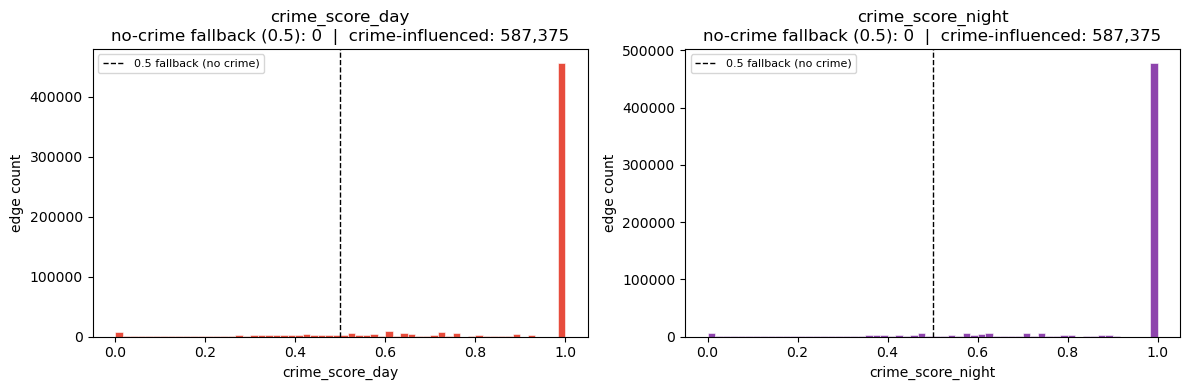

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in [
    (axes[0], "crime_score_day",   "#e74c3c"),
    (axes[1], "crime_score_night", "#8e44ad"),
]:
    data = edges[col]
    no_crime  = (data == 0.5).sum()
    has_crime = (data != 0.5).sum()
    ax.hist(data, bins=60, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="0.5 fallback (no crime)")
    ax.set_title(f"{col}\nno-crime fallback (0.5): {no_crime:,}  |  crime-influenced: {has_crime:,}")
    ax.set_xlabel(col)
    ax.set_ylabel("edge count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## lighting_class_score — Road-Type Lighting Proxy

### What it measures

`lighting_class_score` estimates the **expected illumination level** of an edge based on its OSM highway type. It is used as the lighting signal for the 68.8% of edges that have no streetlight within 30 m and therefore no real `light_score`.

This is not a measurement. It is the same OSM highway tag looked up through a table of expected lighting conditions. Every edge of the same highway type gets the same score regardless of actual conditions on that specific block.

### Why the SD Street Lighting Design Manual was removed

The previous version cited the SD Street Lighting Design Manual (§A.2–§A.6). That manual describes design intent for new road construction — not actual conditions on existing streets.

The real streetlight data exposed a contradiction: the manual would score footways at the lowest tier, but the coverage analysis shows **40.2% of footway edges** have at least one streetlight within 30 m — meaning many footways are genuinely lit, likely because they are in commercial districts, near crossings, or adjacent to lit parking areas. The manual's design-intent values do not reflect observed reality on discretionary road classes.

The new values use first-principles tiered reasoning grounded in legal and operational lighting obligations, cross-checked against the observed streetlight coverage data.

### Tier reasoning

| Tier | Highway types | Score | Rationale |
|---|---|---|---|
| Major arterials | motorway, trunk, primary (+ links) | 0.75–0.90 | Traffic safety statutes require lighting on high-speed multi-lane roads; maintained consistently citywide |
| Secondary / tertiary | secondary, pedestrian, tertiary (+ links) | 0.50–0.65 | Generally lit in urban SD; coverage drops toward suburban fringe |
| Residential | residential, living_street | 0.45 | Variable across SD — neither reliably lit nor reliably dark; neutral estimate |
| Minor / unclassified | unclassified, steps | 0.40 | Conservative neutral; no lighting obligation |
| Service | service (base) | 0.35 | Dark by default; refined by subtype (parking aisle, alley, driveway, etc.) |
| Footways / cycleways | footway, cycleway | 0.30 | Open space exemption; **confirmed by data**: 40.2% coverage means 59.8% have no nearby streetlight |
| Paths | path | 0.20 | Park and beach paths; **confirmed by data**: 9.2% coverage — mostly unlit |
| Tracks / bridleways | track, bridleway | 0.15 | Explicitly unlit off-road surfaces |

### What it gets right

Relative ordering is correct and consistent with both common sense and observed streetlight coverage: arterials score higher than residential, residential higher than footways, footways higher than park paths. The direction of the signal is sound.

### What it doesn't get right

No edge-level variation within a road class. Every residential street gets 0.45 — whether it is a well-lit commercial strip or a dark suburban cul-de-sac. There is no published standard being cited; the values reflect typical US city infrastructure patterns applied to SD.

### Known limitation

This produces **discrete point masses** in the score distribution. 68.8% of edges — those without real streetlight data — receive one of ~13 possible values. Routing on unlit edges effectively reduces to road type classification. This is the primary reason `infrastructure_score` is kept at **15% weight** in the final safety score, so crime and walkability dominate.

### Score direction

Higher = better expected illumination = safer at night.

## Road Type Distribution


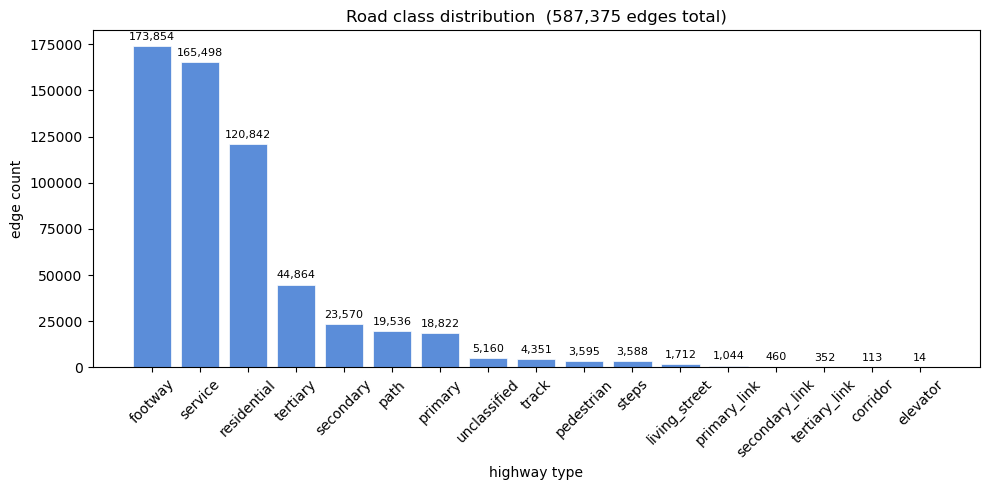

highway
footway           173854
service           165498
residential       120842
tertiary           44864
secondary          23570
path               19536
primary            18822
unclassified        5160
track               4351
pedestrian          3595
steps               3588
living_street       1712
primary_link        1044
secondary_link       460
tertiary_link        352
corridor             113
elevator              14


In [14]:
import matplotlib.pyplot as plt

# Flatten highway lists (OSM sometimes returns a list per edge)
highway_clean = edges["highway"].apply(lambda h: h[0] if isinstance(h, list) else h)
counts = highway_clean.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color="#5b8dd9", edgecolor="white", linewidth=0.5)
ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=3, fontsize=8)
ax.set_title(f"Road class distribution  ({len(edges):,} edges total)")
ax.set_xlabel("highway type")
ax.set_ylabel("edge count")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(counts.to_string())


In [15]:
lights_3857 = light_gdf.to_crs("EPSG:3857")

# Spatial join: count city streetlights within 30 m of each edge
edges_3857 = edges.to_crs("EPSG:3857")
edges_buffered = edges_3857.copy()
edges_buffered["geometry"] = edges_3857.geometry.buffer(30)

joined = gpd.sjoin(edges_buffered[["geometry"]], lights_3857[["geometry"]], how="left", predicate="contains")
raw_lights_counts = joined.groupby(joined.index)["index_right"].count().reindex(edges.index, fill_value=0)

has_lights = raw_lights_counts > 0

print(raw_lights_counts.describe().round(2))
print(f"\nEdges with ≥1 streetlight : {has_lights.sum():,}  ({100*has_lights.mean():.1f}%)")
print(f"Edges with 0 streetlights  : {(~has_lights).sum():,}  ({100*(~has_lights).mean():.1f}%)")
print(f"Max streetlights on one edge: {raw_lights_counts.max():.0f}")
print(f"\np75={raw_lights_counts[has_lights].quantile(0.75):.1f}  "
      f"p80={raw_lights_counts[has_lights].quantile(0.80):.1f}  "
      f"p95={raw_lights_counts[has_lights].quantile(0.95):.1f}")


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


count    587375.00
mean          0.74
std           1.61
min           0.00
25%           0.00
50%           0.00
75%           1.00
max          64.00
Name: index_right, dtype: float64

Edges with ≥1 streetlight : 183,045  (31.2%)
Edges with 0 streetlights  : 404,330  (68.8%)
Max streetlights on one edge: 64

p75=3.0  p80=3.0  p95=6.0


## light_score — Streetlight Presence Signal

### What it measures

`light_score` measures **total streetlight presence** within 30 m of each edge, normalized to [0, 1]. It reflects how much lighting exists near the edge — not lighting density per metre. This is intentional: a pedestrian walking a segment experiences the total illumination in their immediate environment, not lights-per-metre as an abstract rate.

### Data source

City of San Diego streetlight dataset — 55,506 operational streetlights filtered to `STATUS = A` and `MAPNG_STAT_CD ∈ {AB, OP}`. Edges and streetlights are reprojected to EPSG:3857 before the 30 m buffer spatial join so distances are in metres.

### Coverage

**31.2% of edges** (183,045) have at least one streetlight within 30 m and receive a real `light_score`. The remaining **68.8% are NaN** and fall back to `lighting_class_score` (a road-type categorical proxy) inside `infrastructure_score`.

**Why 31.2% and not more:** Three alternatives were evaluated for the 68.8% unlit tail and rejected:
- OSM `lit=yes` tags — too sparse to use as a coverage signal
- Land use polygons — only 20.9% coverage on pedestrian-relevant unlit edges, with residential at 11.2%; below the 40% threshold needed to be useful
- No better alternative exists with complete coverage over the unlit 68.8%

### Normalization

`log1p(raw_count) / p95(log_raw)`, clipped to [0, 1]

**Why log:** Streetlight counts follow a power law — a few intersections and downtown blocks accumulate very high counts while most segments have 1–3. Log compression preserves the ordering while preventing downtown outliers from crushing the mid-range signal.

**Why p95 not max:** A single extreme outlier (a densely instrumented interchange or plaza) would set the max and compress everything else. The 95th percentile is a stable anchor that treats the top 5% as equally "fully lit" and gives meaningful spread to the remaining 95%.

### Why edge length is not normalized

Capped-length density normalization (`lights / clip(length, 1, p80)`) was tested and failed: edges with 2 lights scored systematically *lower* than edges with 1 light because two-light edges are on average longer than one-light edges. The density approach penalised better-lit longer edges. Raw count correctly reflects total illumination a pedestrian experiences walking the full edge.

**Known limitation:** A 400 m edge with 2 lights scores identically to a 20 m edge with 2 lights. In practice this is rare — OSMnx segments streets at intersections, so most edges are short (median 37 m), and long edges that are genuinely well-lit tend to have proportionally more lights anyway.

### Score direction

Higher = more streetlights nearby = better lit = safer at night.

| Score | Meaning |
|---|---|
| 1.0 | Top 5% of streetlight counts — heavily lit |
| 0.5–1.0 | Well-lit segment |
| 0.0–0.5 | Few nearby streetlights |
| NaN | No streetlight within 30 m — falls back to `lighting_class_score` |

Edge length summary (all kept edges, metres):
count    587375.0
mean         70.1
std         111.9
min           0.1
5%            6.1
25%          15.7
50%          37.4
75%          81.7
80%          97.6
90%         164.3
95%         236.2
99%         482.2
max        4779.6
Name: length, dtype: float64

p80 (cap)  : 97.6 m
% edges <= p80 : 80.0%
% edges > p80  : 20.0%


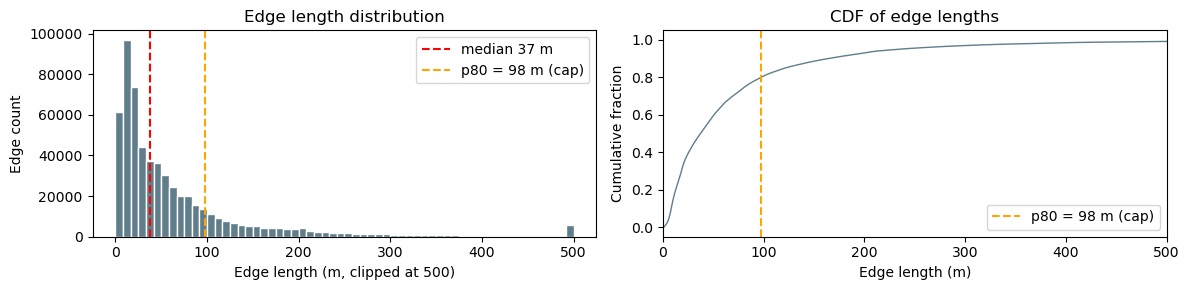

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ── Edge length summary statistics ────────────────────────────────────────────
print("Edge length summary (all kept edges, metres):")
print(edges["length"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]).round(1))

length_p80 = edges["length"].quantile(0.80)
print(f"\np80 (cap)  : {length_p80:.1f} m")
print(f"% edges <= p80 : {(edges['length'] <= length_p80).mean()*100:.1f}%")
print(f"% edges > p80  : {(edges['length'] > length_p80).mean()*100:.1f}%")

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

clipped = edges["length"].clip(upper=500)
axes[0].hist(clipped, bins=60, color="#607D8B", edgecolor="white")
axes[0].axvline(edges["length"].median(), color="red",    linestyle="--", label=f"median {edges['length'].median():.0f} m")
axes[0].axvline(length_p80,              color="orange", linestyle="--", label=f"p80 = {length_p80:.0f} m (cap)")
axes[0].set_xlabel("Edge length (m, clipped at 500)")
axes[0].set_ylabel("Edge count")
axes[0].set_title("Edge length distribution")
axes[0].legend()

sorted_lengths = np.sort(edges["length"].values)
cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1].plot(sorted_lengths, cdf, color="#607D8B", linewidth=1)
axes[1].axvline(length_p80, color="orange", linestyle="--", label=f"p80 = {length_p80:.0f} m (cap)")
axes[1].set_xlim(0, 500)
axes[1].set_xlabel("Edge length (m)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("CDF of edge lengths")
axes[1].legend()

plt.tight_layout()
plt.show()

Lit edges  : 183,045  (31.2%)
Unlit edges: 404,330  (68.8%)
p95 log-count anchor: 1.9459

light_score stats (lit edges only):
count    183045.0000
mean          0.5596
std           0.2050
min           0.3562
25%           0.3562
50%           0.5646
75%           0.7124
max           1.0000
Name: light_score, dtype: float64

Range [0,1] on lit edges: OK
NaN on lit edges: none (OK)
NaN on unlit edges: all NaN (OK)
Top-5 raw count ∩ top-5 light_score overlap: 0/5

Check 1 — road-type ordering (lit edges only, expected: primary > residential > footway):
  primary        0.663
  secondary      0.660
  residential    0.552
  footway        0.580
  path           0.502

Check 2 — long-sparse vs short-dense:
  long(>150m, ≤2 lights): mean=0.484  n=9502
  short(<30m, 4+ lights): mean=0.888  n=9670
  [OK]


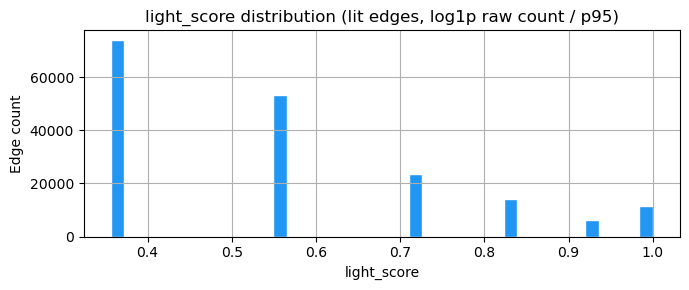

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ── Raw count log normalization ────────────────────────────────────────────────
has_lights = raw_lights_counts > 0

log_raw = np.log1p(raw_lights_counts[has_lights])
p95     = log_raw.quantile(0.95)

edges["light_score"] = np.nan
edges.loc[has_lights,  "light_score"] = (log_raw / p95).clip(0, 1)
edges.loc[~has_lights, "light_score"] = np.nan

print(f"Lit edges  : {has_lights.sum():,}  ({has_lights.mean()*100:.1f}%)")
print(f"Unlit edges: {(~has_lights).sum():,}  ({(~has_lights).mean()*100:.1f}%)")
print(f"p95 log-count anchor: {p95:.4f}")
print("\nlight_score stats (lit edges only):")
print(edges.loc[has_lights, "light_score"].describe().round(4))

# ── Range [0,1] on lit edges ──────────────────────────────────────────────────
assert edges.loc[has_lights, "light_score"].between(0, 1).all(), "FAIL: scores outside [0,1]"
print("\nRange [0,1] on lit edges: OK")

# ── No NaN on lit edges ───────────────────────────────────────────────────────
assert edges.loc[has_lights, "light_score"].notna().all(), "FAIL: NaN on lit edges"
print("NaN on lit edges: none (OK)")

# ── NaN on all unlit edges ────────────────────────────────────────────────────
assert edges.loc[~has_lights, "light_score"].isna().all(), "FAIL: non-NaN on unlit edges"
print("NaN on unlit edges: all NaN (OK)")

# ── Top raw count → top light_score ──────────────────────────────────────────
top5_raw   = set(raw_lights_counts[has_lights].nlargest(5).index.tolist())
top5_score = set(edges.loc[has_lights, "light_score"].nlargest(5).index.tolist())
overlap    = len(top5_raw & top5_score)
print(f"Top-5 raw count ∩ top-5 light_score overlap: {overlap}/5")

# ── Check 1: road-type ordering within lit edges ─────────────────────────────
# Higher-order roads have more streetlights → should score higher than footways/paths
print("\nCheck 1 — road-type ordering (lit edges only, expected: primary > residential > footway):")
for t in ["primary", "secondary", "residential", "footway", "path"]:
    m = edges.loc[(edges["highway"] == t) & has_lights, "light_score"].mean()
    print(f"  {t:<14} {m:.3f}" if not np.isnan(m) else f"  {t:<14} no lit edges")

# ── Check 2: long sparse < short dense ───────────────────────────────────────
long_sparse = edges.loc[(edges["length"] > 150) & (raw_lights_counts <= 2) & has_lights, "light_score"]
short_dense  = edges.loc[(edges["length"] < 30)  & (raw_lights_counts >= 4) & has_lights, "light_score"]
if not long_sparse.empty and not short_dense.empty:
    status = "OK" if short_dense.mean() > long_sparse.mean() else "FAIL"
    print(f"\nCheck 2 — long-sparse vs short-dense:")
    print(f"  long(>150m, ≤2 lights): mean={long_sparse.mean():.3f}  n={len(long_sparse)}")
    print(f"  short(<30m, 4+ lights): mean={short_dense.mean():.3f}  n={len(short_dense)}")
    print(f"  [{status}]")
else:
    print("\nCheck 2 — insufficient edges for comparison")

# ── Distribution ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
edges.loc[has_lights, "light_score"].hist(bins=40, ax=ax, color="#2196F3", edgecolor="white")
ax.set_xlabel("light_score")
ax.set_ylabel("Edge count")
ax.set_title("light_score distribution (lit edges, log1p raw count / p95)")
plt.tight_layout()
plt.show()

In [18]:
# find long edges with very few lights and check their scores
suspicious = edges[has_lights].copy()
suspicious["highway_clean"] = suspicious["highway"].apply(_first)
suspicious["raw_lights"] = raw_lights_counts[has_lights]

long_sparse = suspicious[
    (suspicious["length"] > 150) & 
    (suspicious["raw_lights"] <= 2)
][["highway_clean", "length", "raw_lights", "light_score"]].sort_values("length", ascending=False)

print(f"Long edges (>150m) with only 1-2 lights: {len(long_sparse):,}")
print(long_sparse.head(20))

# compare against short well-lit edges of same road type
short_dense = suspicious[
    (suspicious["length"] < 30) & 
    (suspicious["raw_lights"] >= 4)
][["highway_clean", "length", "raw_lights", "light_score"]].sort_values("light_score", ascending=False)

print(f"\nShort edges (<30m) with 4+ lights: {len(short_dense):,}")
print(short_dense.head(20))

# the key check — short well-lit should score higher than long sparse
long_sparse_mean = long_sparse["light_score"].mean()
short_dense_mean = short_dense["light_score"].mean()
print(f"\nLong sparse mean score: {long_sparse_mean:.3f}")
print(f"Short dense mean score: {short_dense_mean:.3f}")
print(f"Short dense > long sparse: {'PASS' if short_dense_mean > long_sparse_mean else 'FAIL'}")

Long edges (>150m) with only 1-2 lights: 9,502
                            highway_clean       length  raw_lights  \
u           v           key                                          
9130894004  9130894004  0            path  3901.296351           2   
                        1            path  3901.296351           2   
5109826929  5109826840  1         footway  2842.104834           1   
5109826840  5109826929  0         footway  2842.104834           1   
8086670352  2699222070  0            path  2365.836010           2   
2699222070  8086670352  0            path  2365.836010           2   
3624799320  3624799320  1            path  2178.662560           1   
                        0            path  2178.662560           1   
5634209213  11357323361 0         primary  2130.753275           2   
11357323361 5634209213  0         primary  2130.753275           2   
11357346482 5634209214  0         primary  2128.547992           2   
5634209214  11357346482 0         primary  

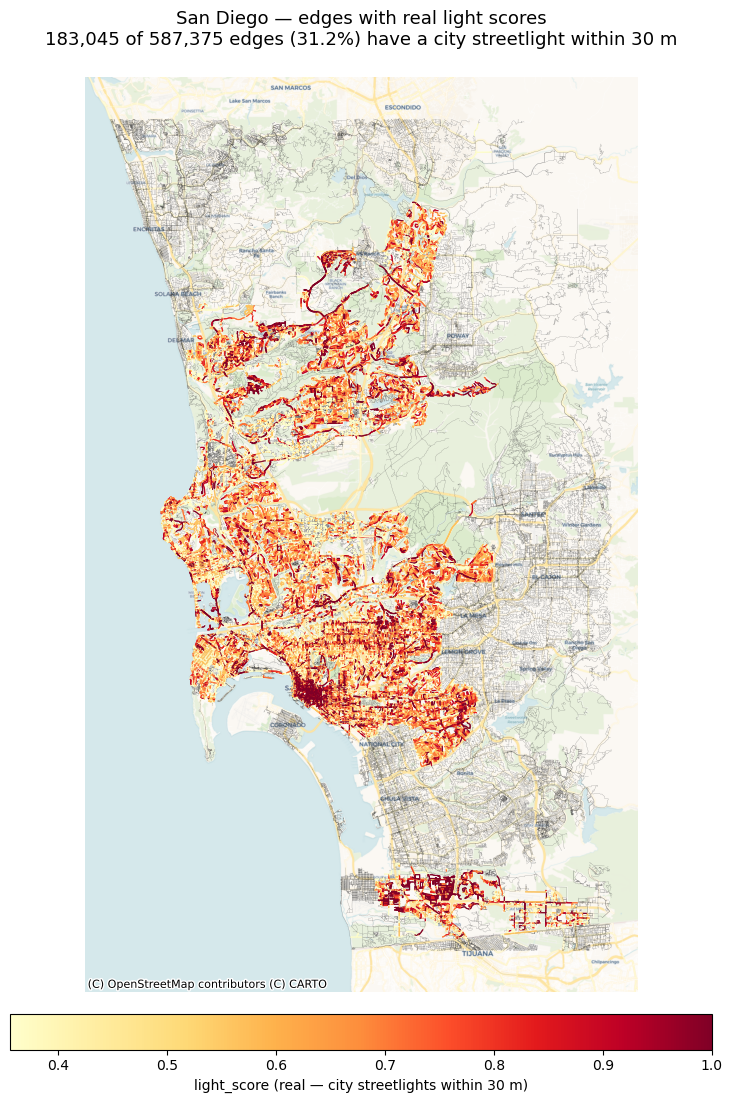

In [19]:
import matplotlib.pyplot as plt
import contextily as ctx

# Plot in EPSG:3857 (Web Mercator) so contextily tiles align correctly
real_edges = edges.loc[raw_lights_counts > 0].to_crs('EPSG:3857')
bg_edges   = edges.to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(12, 12))

# Faint network background so roads are visible over the basemap
bg_edges.plot(ax=ax, color='#555555', linewidth=0.2, alpha=0.3, zorder=2)

# Real-scored edges coloured by light_score
real_edges.plot(
    ax=ax,
    column='light_score',
    cmap='YlOrRd',
    linewidth=0.8,
    alpha=0.9,
    legend=True,
    legend_kwds={
        'label': 'light_score (real — city streetlights within 30 m)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02,
    },
    zorder=3,
)

# Basemap — CartoDB Voyager shows water, parks, and land clearly
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=12, zorder=1)

ax.set_title(
    f'San Diego — edges with real light scores\n'
    f'{len(real_edges):,} of {len(edges):,} edges ({100*len(real_edges)/len(edges):.1f}%) '
    f'have a city streetlight within 30 m',
    fontsize=13, pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


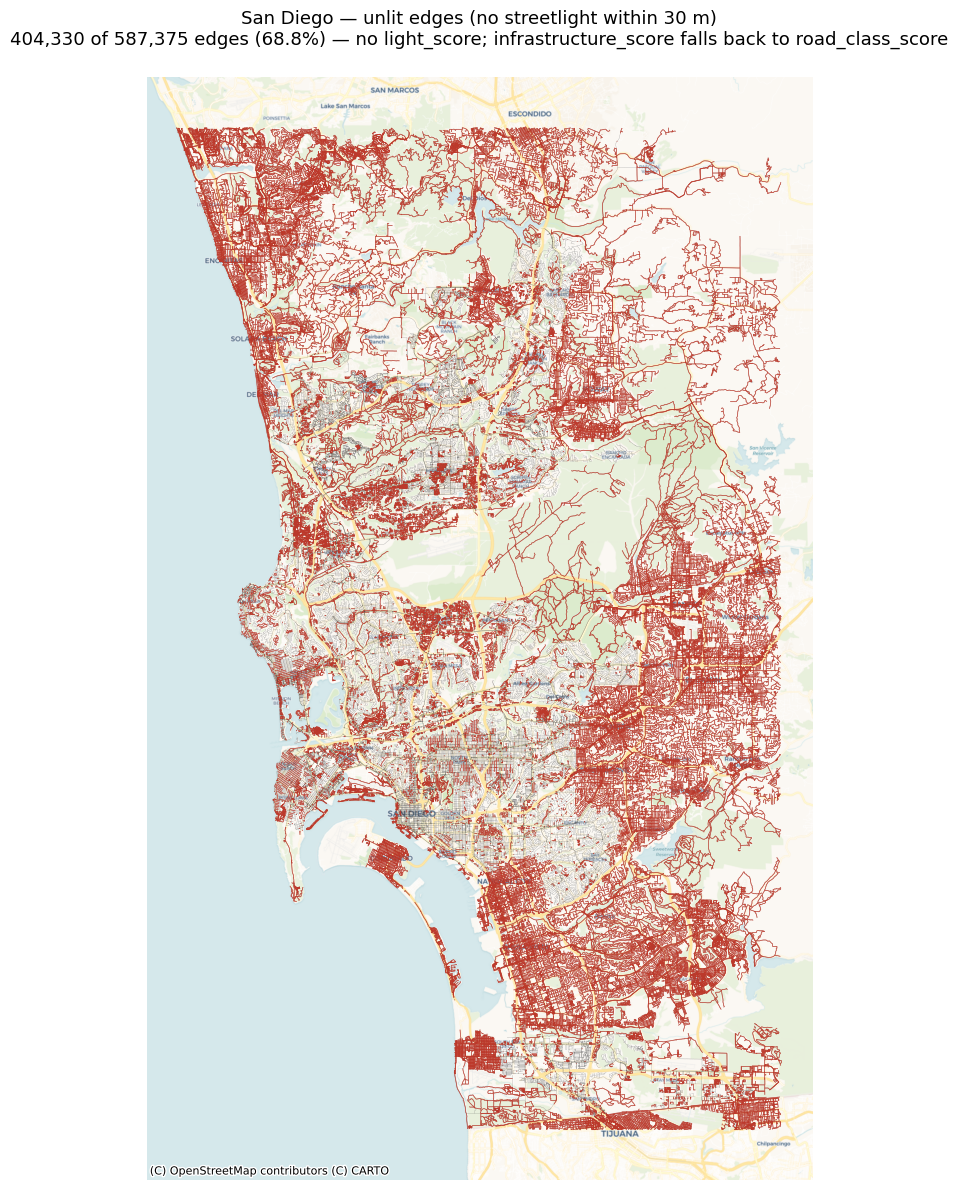

In [20]:
import matplotlib.pyplot as plt
import contextily as ctx

unlit_edges = edges.loc[raw_lights_counts == 0].to_crs('EPSG:3857')
bg_edges    = edges.to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(12, 12))

bg_edges.plot(ax=ax, color='#555555', linewidth=0.2, alpha=0.3, zorder=2)
unlit_edges.plot(ax=ax, color='#c0392b', linewidth=0.5, alpha=0.6, zorder=3)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=12, zorder=1)

ax.set_title(
    f'San Diego — unlit edges (no streetlight within 30 m)\n'
    f'{len(unlit_edges):,} of {len(edges):,} edges ({100*len(unlit_edges)/len(edges):.1f}%) '
    f'— no light_score; infrastructure_score falls back to road_class_score',
    fontsize=13, pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [21]:
edges['light_score'].describe()

count    183045.000000
mean          0.559609
std           0.204958
min           0.356207
25%           0.356207
50%           0.564575
75%           0.712414
max           1.000000
Name: light_score, dtype: float64

## Score Distribution Checks

Verify each score is not degenerate — no extreme skew, no mass at a single value, ordering consistent with expectations.

Lit edges (have light_score)  : 183,045 (31.2%)
Unlit edges (light_score=NaN) : 404,330 (68.8%)


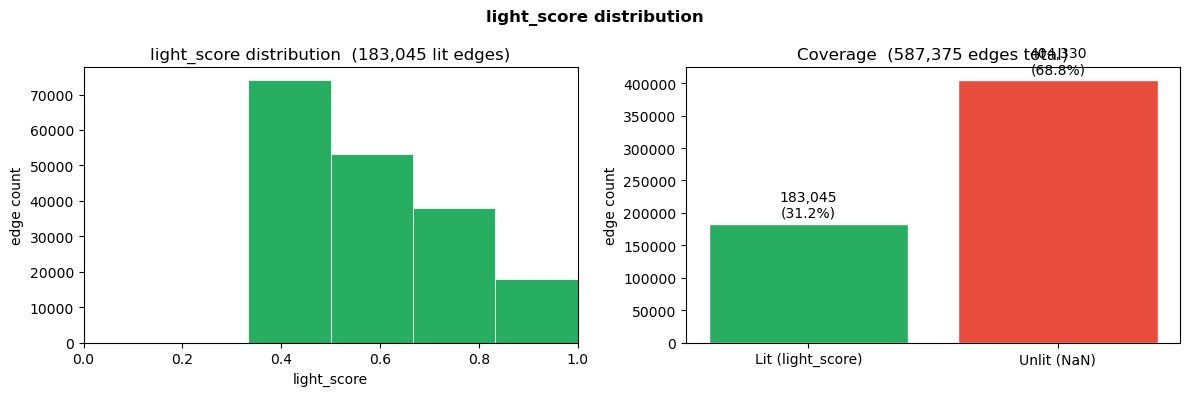

In [22]:
import matplotlib.pyplot as plt
import numpy as np

real_scores = edges.loc[raw_lights_counts > 0, "light_score"]
unlit_count = (raw_lights_counts == 0).sum()

print(f"Lit edges (have light_score)  : {len(real_scores):,} ({100*len(real_scores)/len(edges):.1f}%)")
print(f"Unlit edges (light_score=NaN) : {unlit_count:,} ({100*unlit_count/len(edges):.1f}%)")

p95_val   = raw_lights_counts[raw_lights_counts > 0].quantile(0.95)
real_bins = np.linspace(0, 1, max(int(p95_val), 5) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(real_scores, bins=real_bins, color="#27ae60", edgecolor="white", linewidth=0.6)
axes[0].set_title(f"light_score distribution  ({len(real_scores):,} lit edges)")
axes[0].set_xlabel("light_score")
axes[0].set_ylabel("edge count")
axes[0].set_xlim(0, 1)

axes[1].bar(["Lit (light_score)", "Unlit (NaN)"],
            [len(real_scores), unlit_count],
            color=["#27ae60", "#e74c3c"], edgecolor="white")
axes[1].set_title(f"Coverage  ({len(edges):,} edges total)")
axes[1].set_ylabel("edge count")
axes[1].bar_label(
    axes[1].containers[0],
    labels=[f"{len(real_scores):,}\n({100*len(real_scores)/len(edges):.1f}%)",
            f"{unlit_count:,}\n({100*unlit_count/len(edges):.1f}%)"],
    padding=3
)

plt.suptitle("light_score distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## light_score coverage — pedestrian-relevant edges only

Service roads (`service`, ~260k edges) pull the headline coverage down to 28.8%, but they are excluded from routing. Stripping them out reveals a different picture:

| Highway type | Total edges | Lit (real data) | Unlit (fallback) | Coverage |
|---|---|---|---|---|
| `primary` | 18,822 | 8,456 | 10,366 | **44.9%** |
| `secondary` | 23,570 | 9,458 | 14,112 | **40.1%** |
| `footway` | 173,854 | 69,918 | 103,936 | **40.2%** |
| `tertiary` | 44,864 | 17,409 | 27,455 | **38.8%** |
| `residential` | 120,842 | 46,478 | 74,364 | **38.5%** |
| `path` | 19,536 | 1,793 | 17,743 | 9.2% |
| `pedestrian` | 3,595 | 632 | 2,963 | 17.6% |
| `steps` | 3,588 | 671 | 2,917 | 18.7% |

Every road type a pedestrian would actually use sits at **~38–45% real coverage**. `path`, `pedestrian`, and `steps` are low because there is no city obligation to light open-space infrastructure — no requirement, so no data.

### Decision

- **Keep `light_score`.** At ~40% coverage on walkable edges it adds genuine granularity: it identifies *which specific* footways and residential streets are actually lit, not just that they typically are.
- **Exclude `service` roads from coverage reporting** — they are not routable and inflate the unlit count by ~220k edges, making coverage appear worse than it is for pedestrian routing.

      highway  total   lit  unlit  coverage
      primary  18822  8456  10366 44.926150
      footway 173854 69918 103936 40.216504
    secondary  23570  9458  14112 40.127280
     tertiary  44864 17409  27455 38.803941
  residential 120842 46478  74364 38.461793
 unclassified   5160  1320   3840 25.581395
living_street   1712   430   1282 25.116822
        steps   3588   671   2917 18.701226
   pedestrian   3595   632   2963 17.579972
         path  19536  1793  17743  9.177928

All pedestrian-relevant edges: 415,543
  Lit   : 156,565  (37.7%)
  Unlit : 258,978  (62.3%)


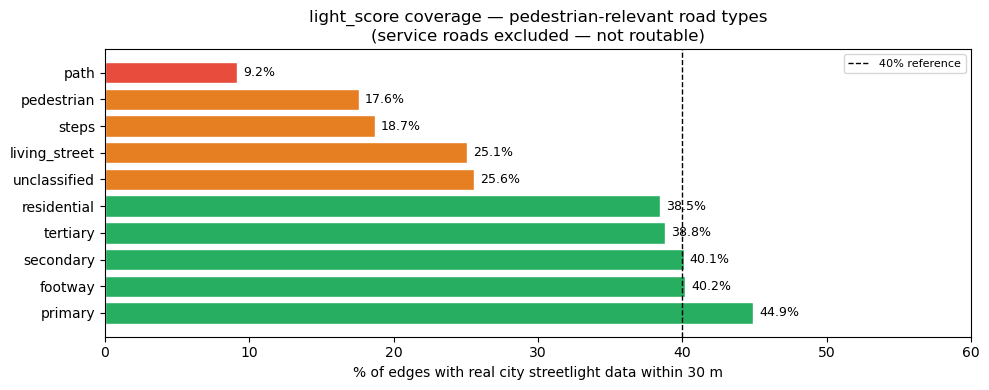

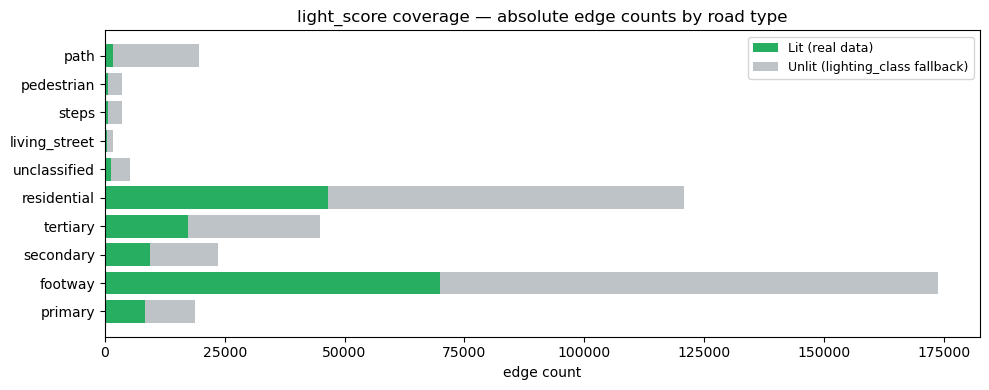

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Pedestrian-relevant road types only — service roads excluded (not routable)
PEDESTRIAN_TYPES = [
    "footway", "residential", "primary", "secondary", "tertiary",
    "path", "pedestrian", "steps", "cycleway", "living_street", "unclassified",
]

highway_flat = edges["highway"].apply(lambda h: h[0] if isinstance(h, list) else h)
ped_mask = highway_flat.isin(PEDESTRIAN_TYPES)

rows = []
for ht in PEDESTRIAN_TYPES:
    mask = highway_flat == ht
    total = mask.sum()
    if total == 0:
        continue
    lit   = (mask & has_lights).sum()
    unlit = total - lit
    rows.append({"highway": ht, "total": total, "lit": lit, "unlit": unlit,
                 "coverage": 100 * lit / total})

import pandas as pd
coverage_df = pd.DataFrame(rows).sort_values("coverage", ascending=False)
print(coverage_df.to_string(index=False))
print(f"\nAll pedestrian-relevant edges: {ped_mask.sum():,}")
print(f"  Lit   : {(ped_mask & has_lights).sum():,}  ({100*(ped_mask & has_lights).sum()/ped_mask.sum():.1f}%)")
print(f"  Unlit : {(ped_mask & ~has_lights).sum():,}  ({100*(ped_mask & ~has_lights).sum()/ped_mask.sum():.1f}%)")

# ── Bar chart: coverage % by road type ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#27ae60" if c >= 35 else "#e67e22" if c >= 15 else "#e74c3c"
          for c in coverage_df["coverage"]]
bars = ax.barh(coverage_df["highway"], coverage_df["coverage"], color=colors, edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in coverage_df["coverage"]], padding=4, fontsize=9)
ax.axvline(40, color="black", linestyle="--", linewidth=1, label="40% reference")
ax.set_xlabel("% of edges with real city streetlight data within 30 m")
ax.set_title("light_score coverage — pedestrian-relevant road types\n(service roads excluded — not routable)")
ax.set_xlim(0, 60)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Stacked bar: absolute edge counts ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(coverage_df["highway"], coverage_df["lit"],   color="#27ae60", label="Lit (real data)")
ax.barh(coverage_df["highway"], coverage_df["unlit"], left=coverage_df["lit"],
        color="#bdc3c7", label="Unlit (lighting_class fallback)")
ax.set_xlabel("edge count")
ax.set_title("light_score coverage — absolute edge counts by road type")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Walkability Score per Edge

### What walk_score actually is

`walk_score` is a **neighbourhood design quality signal** derived from the EPA National Walkability Index (`NatWalkInd`). It measures how likely people in a census block group are to *choose* walking as transportation, based on the physical design of the built environment — not crime history, not specific road conditions. Scale 1–20, normalised to [0, 1] via `(NatWalkInd - 1) / 19`.

---

### The four underlying variables

The index is built from four block-group-level measurements, combined into three equally-weighted dimensions:

| Variable | Dimension | What it measures |
|---|---|---|
| `D2A_EPHHM` | Employment + housing mix | Diversity of jobs AND housing together in a block group. High score = mixed-use urban area with office, retail, service jobs co-located with residents. Low score = pure residential suburb or pure industrial zone. |
| `D2B_E8MIXA` | Employment type mix | How diverse the *types* of jobs are — retail, office, industrial, service. Diverse employment means more people moving around at different times of day. |
| `D3B` | Intersection density | Pedestrian-oriented intersections per square mile. **The most directly useful variable for SafePath.** Dense grids = shorter blocks, more route options, more natural surveillance. Cul-de-sac suburbs score low. |
| `D4A` | Transit accessibility | Proximity and frequency of transit stops. Less directly relevant since SafePath users are already choosing to walk, but correlates strongly with overall pedestrian activity levels. |

**Dimension weights:** employment mix (D2A + D2B combined) ⅓ · intersection density (D3B) ⅓ · transit (D4A) ⅓.

---

### How it maps to edges

1. Reproject edges and census block group polygons to EPSG:3857.
2. Compute the **midpoint** of each edge via `interpolate(0.5, normalized=True)` — a single point that lands unambiguously inside one polygon. Avoids double-counting when a long edge crosses two block groups.
3. Spatial join: assign the `NatWalkInd` of whichever polygon the midpoint falls within (`predicate="within"`).
4. Normalise: `walk_score = (NatWalkInd - 1) / 19`
5. Edges outside any polygon — parks, military land, coastal paths — get a **0.5 neutral fallback**.

**Source:** `data/processed/walkability_final_gdf.gpkg` — EPA Walkability Index joined to San Diego census block groups.

---

### Why it's the right third signal for SafePath

`walk_score` fills a gap that neither `crime_score` nor `infrastructure_score` can cover:

| Signal | What it measures | Limitation |
|---|---|---|
| `crime_score` | Where bad things have *happened* | Reactive, historical — silent on areas with low reporting |
| `infrastructure_score` | Physical conditions of the specific edge | Edge-level only — blind to neighbourhood context |
| `walk_score` | What kind of *neighbourhood* you're routing through | Proactive, environmental — captures the context both other signals miss |

The underlying principle is Jane Jacobs' **"eyes on the street"** — dense mixed-use neighbourhoods with active street life deter crime and make pedestrians feel safer because natural surveillance is high. The EPA index operationalises this through intersection density (`D3B`) and employment mix (`D2A`, `D2B`).

The practical routing implication: `walk_score` correctly differentiates two routes with similar crime histories — one through a walkable mixed-use corridor, one through an industrial zone or suburban fringe — in favour of the walkable one, even when crime data can't make that distinction.

**At ~22% weight** it influences macro routing decisions (neighbourhood-level) without overriding `crime_score` on specific dangerous corridors (edge-level). Neighbourhood context informs the route; edge-level danger signals make the final call.

---

### Score direction

Higher = more walkable neighbourhood = safer pedestrian environment by design.

| Score | Meaning |
|---|---|
| 0.8–1.0 | Dense mixed-use urban core — high natural surveillance, frequent intersections |
| 0.5–0.8 | Moderate walkability — transitional or inner suburban areas |
| 0.2–0.5 | Low walkability — suburban fringe, industrial, auto-oriented |
| 0.5 | Fallback — edge outside any census block group (parks, military, coast) |


In [24]:

# Reproject to match edges
walk_gdf_3857 = walkability_gdf.to_crs("EPSG:3857")

# Midpoint of each edge
#  interpolate(0.5, normalized=True) gives the midpoint along the edge geometry
edges_mid = edges_3857.copy()
edges_mid["geometry"] = edges_mid.geometry.interpolate(0.5, normalized=True)

# Spatial join midpoint with walkability block group polygon
# predicate: "within" — only assign walkability score if midpoint falls within the block group polygon
# only need NatWalkInd and geometry from walkability_gdf for this join

joined_walk = gpd.sjoin(edges_mid[["geometry"]],
                        walk_gdf_3857[["NatWalkInd", "geometry"]],
                        how="left",
                        predicate="within")

# Normalize NatWalkInd to 0-1 range
edges['walk_score'] = ((joined_walk["NatWalkInd"] - 1)/19).fillna(0.5).values


In [25]:
# Check 1 — fallback rate
walk_fallback = (edges["walk_score"] == 0.5).sum()
print(f"Walk fallback: {walk_fallback:,} ({100*walk_fallback/len(edges):.1f}%)")

# Check 2 — real score variation
real_walk = edges[edges["walk_score"] != 0.5]["walk_score"]
print(real_walk.describe())

Walk fallback: 203,900 (34.7%)
count    383475.000000
mean          0.605681
std           0.200767
min           0.052632
25%           0.438596
50%           0.640351
75%           0.754386
max           0.982456
Name: walk_score, dtype: float64


count    587375.000000
mean          0.568995
std           0.169842
min           0.052632
25%           0.500000
50%           0.500000
75%           0.701754
max           0.982456
Name: walk_score, dtype: float64
Any above 1? False
Any below 0? False


<Axes: >

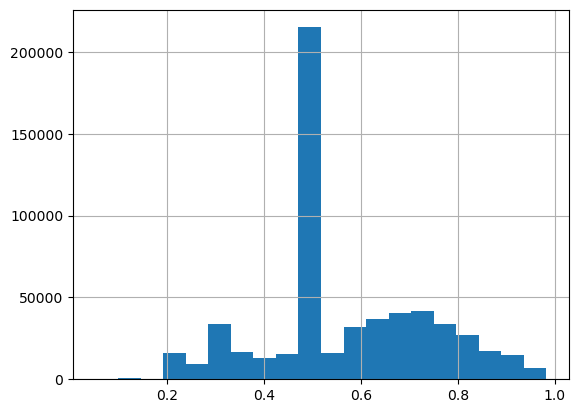

In [26]:
# Sanity Check 
print(edges["walk_score"].describe())
print("Any above 1?", (edges["walk_score"] > 1).any())
print("Any below 0?", (edges["walk_score"] < 0).any())

# Also check distribution looks reasonable
# Most San Diego edges should cluster around 0.4-0.7
edges["walk_score"].hist(bins=20)


In [27]:
# How many edges got a real score vs the 0.5 fallback
real_scores = (edges["walk_score"] != 0.5).sum()
fallback = (edges["walk_score"] == 0.5).sum()
print(f"Real scores: {real_scores}")
print(f"Fallback 0.5: {fallback}")

# Check CRS of both before the join
print(edges_mid.crs)
print(walk_gdf_3857.crs)

# Check if midpoints are actually inside San Diego bbox
print(edges_mid.geometry.total_bounds)
print(walk_gdf_3857.geometry.total_bounds)

Real scores: 383475
Fallback 0.5: 203900
EPSG:3857
EPSG:3857
[-13060416.63674213   3833612.4935482  -13014098.03930676
   3910485.46244185]
[-13090788.5103237    3833714.55559786 -12958859.55164394
   3962531.04870774]


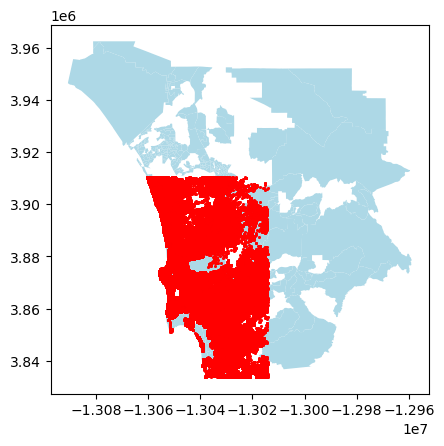

In [28]:
# Plot both to visually confirm they overlap
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
walk_gdf_3857.plot(ax=ax, color="lightblue")
edges_mid.plot(ax=ax, color="red", markersize=1)
plt.show()

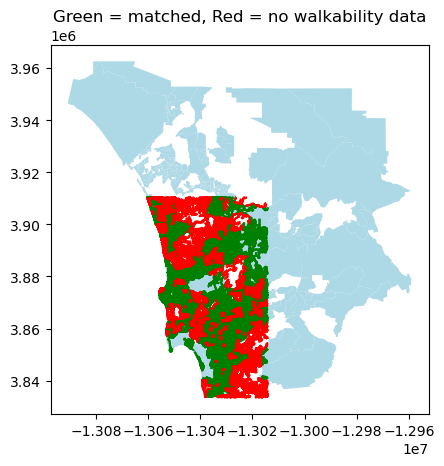

In [29]:
# Plot just the unmatched edges to see where they are
unmatched = edges[edges["walk_score"] == 0.5]
matched = edges[edges["walk_score"] != 0.5]

fig, ax = plt.subplots()
walk_gdf_3857.plot(ax=ax, color="lightblue")
matched.to_crs("EPSG:3857").plot(ax=ax, color="green", markersize=1)
unmatched.to_crs("EPSG:3857").plot(ax=ax, color="red", markersize=1)
plt.title("Green = matched, Red = no walkability data")
plt.show()

### Why are ~35% of edges red (no walkability match)?

Red edges received the 0.5 fallback because their midpoint didn't land inside any census block group polygon. This is expected and breaks down into a few well-understood categories.

**Large red zone on the west — ocean and coastline**
Census block groups are land-based administrative units. No block group geometry covers open water, so every walking path along the coast — boardwalks, beach paths, pier walkways — falls back to 0.5. This is not a data error.

**Scattered red patches through the city — parks, military land, and non-residential zones**

| Area | Why no block group |
| - | - |
| Balboa Park | San Diego's largest urban park has extensive OSM walking paths but no residential block group covers it |
| Mission Bay / Mission Valley | Water and recreational parkland with walking paths but no residential census coverage |
| MCAS Miramar, NAS North Island, Naval Station SD | Federal military land — no civilian census block groups exist on base |
| Industrial and commercial zones | Areas with zero residential population are often outside any block group boundary |

**What this means for routing**
These edges are not broken — they just have no walkability data. The 0.5 fallback is deliberately neutral: the router will not prefer or avoid them on walkability grounds alone. Crime and lighting scores still apply to all edges including these, so routing still functions correctly in parks, along the coast, and near military areas.

In [30]:
# Pedestrian suitability: higher = more appropriate for walking.
# Reflects traffic exposure and road designation, not lighting.
road_class_map = {
    "footway":       1.00,
    "pedestrian":    1.00,
    "path":          0.90,
    "cycleway":      0.85,
    "living_street": 0.80,
    "residential":   0.70,
    "unclassified":  0.60,
    "tertiary":      0.50,
    "secondary":     0.35,
    "primary":       0.20,
    "trunk":         0.10,
    "motorway":      0.00,
}

def get_road_class_score(val):
    if isinstance(val, list):
        val = val[0]
    return road_class_map.get(val, 0.5)

edges["road_class_score"] = edges["highway"].map(get_road_class_score)

print("road_class_score value counts (score → count):")
print(edges["road_class_score"].value_counts().sort_index(ascending=False).to_string())
print()
print(edges["road_class_score"].describe().round(3))
print()
fallback_road = (edges["road_class_score"] == 0.5).sum()
print(f"Fallback 0.5 edges (highway not in map): {fallback_road:,}  ({100*fallback_road/len(edges):.1f}%)")


road_class_score value counts (score → count):
road_class_score
1.00    177449
0.90     19536
0.80      1712
0.70    120842
0.60      5160
0.50    220284
0.35     23570
0.20     18822

count    587375.000
mean          0.692
std           0.238
min           0.200
25%           0.500
50%           0.700
75%           1.000
max           1.000
Name: road_class_score, dtype: float64

Fallback 0.5 edges (highway not in map): 220,284  (37.5%)


In [31]:
# Expected illumination by road class — used as lighting signal for unlit edges.
# Tiered by legal/operational lighting obligation, not a published design standard.
# Only contains highway types present in the filtered walk network.
LIGHTING_CLASS = {
    "primary":       0.80,  "primary_link":   0.75,  # primary arterials, consistently lit citywide
    "secondary":     0.65,  "secondary_link": 0.60,  # generally lit in urban SD, drops toward suburban fringe
    "pedestrian":    0.65,                           # commercial pedestrian areas, typically lit
    "tertiary":      0.55,  "tertiary_link":  0.50,  # partial coverage, near transit or commercial
    "residential":   0.45,  "living_street":  0.45,  # variable across SD — honest neutral estimate
    "unclassified":  0.40,  "steps":          0.40,  # minor roads — conservative neutral
    "service":       0.35,                           # dark by default (refined by subtype below)
    "footway":       0.30,  "cycleway":       0.30,  # open space exemption; real data: 40.2% coverage confirms most are unlit
    "path":          0.20,                           # park/beach paths; real data: 9.2% coverage confirms mostly unlit
    "track":         0.15,                           # off-road surface, unlit
}
# Excluded: motorway, motorway_link — not present in OSMnx walk network
#           trunk, trunk_link — expressways, filtered out
#           bridleway — filtered out

def _first(val):
    return val[0] if isinstance(val, list) else val

edges["lighting_class_score"] = edges["highway"].apply(_first).map(LIGHTING_CLASS).fillna(0.40)

# Refine service edges by OSM subtype.
# Only subtypes kept by the walk network filter are listed here.
SERVICE_LIGHTING = {
    "drive-through": 0.55,  # commercial, lit during operation hours
    "car_wash":      0.45,  # commercial, usually lit
    "access":        0.35,  # generic — keep base score
    "alley":         0.30,  # lowest-priority luminaire class
}
# Excluded: parking_aisle, parking, driveway, emergency_access, slipway, yard
#           (all filtered out via DROP_SERVICE)

if "service" in edges.columns:
    service_idx = edges.index[edges["highway"].apply(_first) == "service"]
    subtypes    = edges.loc[service_idx, "service"].apply(_first)
    refined     = subtypes.map(SERVICE_LIGHTING)
    has_subtype = refined.notna()
    known_idx   = service_idx[has_subtype.values]
    edges.loc[known_idx, "lighting_class_score"] = refined[has_subtype].values
    print(f"Service subtype refinement: {has_subtype.sum():,} of {len(service_idx):,} service edges refined")

print("\nlighting_class_score value counts:")
print(edges["lighting_class_score"].value_counts().sort_index(ascending=False).to_string())

Service subtype refinement: 15,156 of 165,498 service edges refined

lighting_class_score value counts:
lighting_class_score
0.80     18822
0.75      1044
0.65     27165
0.60       460
0.55     46771
0.50       352
0.45    122556
0.40      8875
0.35    150346
0.30    187097
0.20     19536
0.15      4351


## infrastructure_score — Physical Environment Signal

### What it measures

`infrastructure_score` captures the physical environment quality of each edge for pedestrian safety, combining a lighting signal with pedestrian road suitability.

### Formula

`infrastructure_score = 0.5 × lighting_signal + 0.5 × road_class_score`

Equal weights because the two dimensions carry independent safety information: a well-lit footway is safer than a dark footway, and a footway is safer than a secondary road regardless of lighting.

### Two populations

Because only 31.2% of edges have real streetlight data, the lighting signal differs by population:

| Population | Size | Lighting signal | Source |
|---|---|---|---|
| **Lit edges** | 31.2% | `light_score` — continuous [0, 1] from log-normalized raw streetlight count | SD streetlight inventory |
| **Unlit edges** | 68.8% | `lighting_class_score` — discrete [0.15–0.90] by OSM highway type | First-principles tier reasoning |

### What lighting_class_score is

For unlit edges, `infrastructure_score` is entirely road-type-based inference. The same OSM highway tag is looked up twice through two different lenses — expected lighting level and pedestrian suitability — and averaged. There is no measured physical data for these edges.

`lighting_class_score` gets the relative ordering right (arterials > residential > paths) but assigns identical scores to every edge of the same road class regardless of actual conditions.

### What road_class_score is

Pedestrian suitability by OSM highway type — complete coverage across all edges. Scores range from 1.00 (footway, pedestrian, path, steps) down to 0.00 (motorway, trunk). Independent of lighting.

### Key distinction

A lit residential edge always outscores an unlit residential edge in `infrastructure_score`, because real `light_score` (even for a sparsely lit segment) will exceed the `lighting_class_score` fallback of 0.45 once any streetlight is nearby. Actual evidence of lighting beats the categorical prior.

### Known limitation

68.8% of edges produce near-discrete `infrastructure_score` values. Routing on unlit edges reduces to road type classification — the score distinguishes road classes but not individual edges within a class. This is why `infrastructure_score` carries only **15% weight** in the final safety score, keeping crime (63%) and walkability (22%) as the dominant signals.

In [32]:
# ── Two-population formula ────────────────────────────────────────────────────
# Lit   (31.2%): real light_score + road suitability
# Unlit (68.8%): road-type lighting proxy + road suitability

edges["infrastructure_score"] = np.nan

edges.loc[has_lights, "infrastructure_score"] = (
    0.5 * edges.loc[has_lights, "light_score"] +
    0.5 * edges.loc[has_lights, "road_class_score"]
)
edges.loc[~has_lights, "infrastructure_score"] = (
    0.5 * edges.loc[~has_lights, "lighting_class_score"] +
    0.5 * edges.loc[~has_lights, "road_class_score"]
)

# ── Range [0,1] all edges ─────────────────────────────────────────────────────
ok_range = edges["infrastructure_score"].between(0, 1).all()
print(f"Range [0,1]: {'OK' if ok_range else 'FAIL'}")

# ── No NaN anywhere ───────────────────────────────────────────────────────────
nan_count = edges["infrastructure_score"].isna().sum()
print(f"NaN count  : {nan_count}  ({'OK' if nan_count == 0 else 'FAIL'})")

# ── Road-type ordering ────────────────────────────────────────────────────────
print("\nRoad-type ordering (expected: footway > residential > tertiary > primary):")
for t in ["footway", "residential", "tertiary", "primary"]:
    m = edges.loc[edges["highway"] == t, "infrastructure_score"].mean()
    print(f"  {t:<14} {m:.3f}" if not np.isnan(m) else f"  {t:<14} no edges")

# ── Lit > unlit same road type ────────────────────────────────────────────────
print("\nLit vs unlit same road type (lit should be higher):")
for t in ["footway", "residential", "tertiary"]:
    lit_m   = edges.loc[(edges["highway"] == t) & has_lights,  "infrastructure_score"].mean()
    unlit_m = edges.loc[(edges["highway"] == t) & ~has_lights, "infrastructure_score"].mean()
    if np.isnan(lit_m) or np.isnan(unlit_m):
        print(f"  {t:<14} insufficient data")
    else:
        status = "OK" if lit_m >= unlit_m else "FAIL"
        print(f"  {t:<14} lit={lit_m:.3f}  unlit={unlit_m:.3f}  [{status}]")

# ── Overall lit vs unlit ──────────────────────────────────────────────────────
lit_mean   = edges.loc[has_lights,  "infrastructure_score"].mean()
unlit_mean = edges.loc[~has_lights, "infrastructure_score"].mean()
print(f"\nMean infrastructure_score — lit={lit_mean:.3f}  unlit={unlit_mean:.3f}")

Range [0,1]: OK
NaN count  : 0  (OK)

Road-type ordering (expected: footway > residential > tertiary > primary):
  footway        0.706
  residential    0.595
  tertiary       0.530
  primary        0.469

Lit vs unlit same road type (lit should be higher):
  footway        lit=0.790  unlit=0.650  [OK]
  residential    lit=0.626  unlit=0.575  [OK]
  tertiary       lit=0.537  unlit=0.525  [OK]

Mean infrastructure_score — lit=0.643  unlit=0.531


In [33]:
# Sanity checks
ok_range = ((edges['infrastructure_score'] >= 0) & (edges['infrastructure_score'] <= 1)).all()
ok_nan   = edges['infrastructure_score'].notna().all()
print('Range [0, 1]:', 'PASS' if ok_range else 'FAIL')
print('No NaN:      ', 'PASS' if ok_nan   else 'FAIL')

if 'service' in edges.columns:
    svc = edges[edges['highway'].apply(_first) == 'service'].copy()
    svc['subtype'] = svc['service'].apply(_first)
    parking = svc.loc[svc['subtype'] == 'parking_aisle', 'infrastructure_score'].mean()
    alley   = svc.loc[svc['subtype'] == 'alley',          'infrastructure_score'].mean()
    if pd.notna(parking) and pd.notna(alley):
        print(f'parking_aisle ({parking:.3f}) > alley ({alley:.3f}):', 'PASS' if parking > alley else 'FAIL')


Range [0, 1]: PASS
No NaN:       PASS


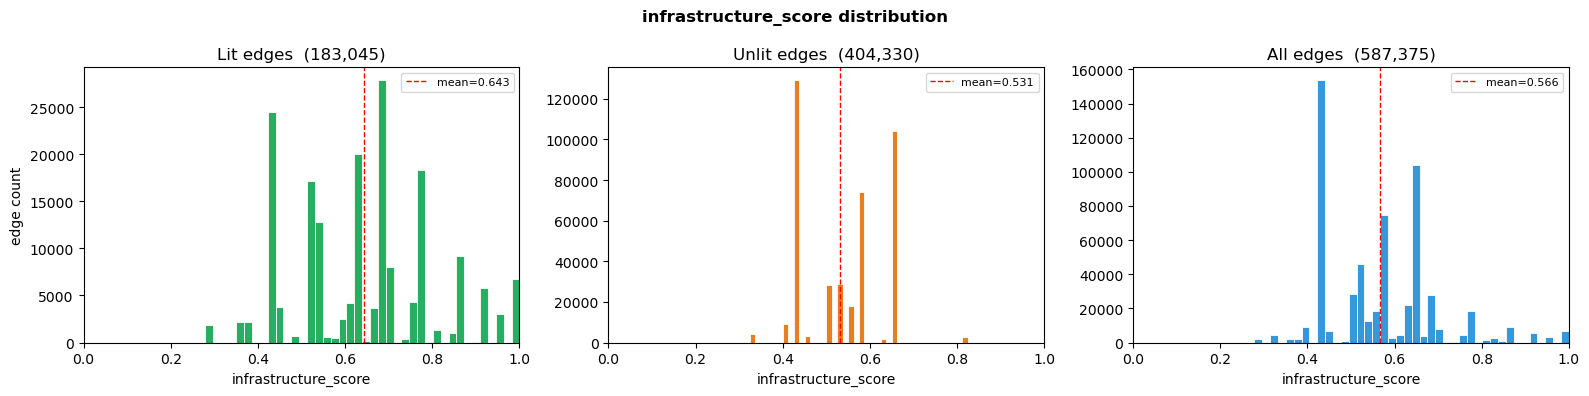

In [34]:
import matplotlib.pyplot as plt
import numpy as np

lit_scores   = edges.loc[has_lights,  'infrastructure_score']
unlit_scores = edges.loc[~has_lights, 'infrastructure_score']

lit_mean   = lit_scores.mean()
unlit_mean = unlit_scores.mean()
all_mean   = edges['infrastructure_score'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(lit_scores,   bins=40, color='#27ae60', edgecolor='white', linewidth=0.6)
axes[0].axvline(lit_mean, color='red', linewidth=1, linestyle='--', label=f'mean={lit_mean:.3f}')
axes[0].set_title(f'Lit edges  ({len(lit_scores):,})')
axes[0].set_xlabel('infrastructure_score')
axes[0].set_ylabel('edge count')
axes[0].set_xlim(0, 1)
axes[0].legend(fontsize=8)

axes[1].hist(unlit_scores, bins=40, color='#e67e22', edgecolor='white', linewidth=0.6)
axes[1].axvline(unlit_mean, color='red', linewidth=1, linestyle='--', label=f'mean={unlit_mean:.3f}')
axes[1].set_title(f'Unlit edges  ({len(unlit_scores):,})')
axes[1].set_xlabel('infrastructure_score')
axes[1].set_xlim(0, 1)
axes[1].legend(fontsize=8)

axes[2].hist(edges['infrastructure_score'], bins=40, color='#3498db', edgecolor='white', linewidth=0.6)
axes[2].axvline(all_mean, color='red', linewidth=1, linestyle='--', label=f'mean={all_mean:.3f}')
axes[2].set_title(f'All edges  ({len(edges):,})')
axes[2].set_xlabel('infrastructure_score')
axes[2].set_xlim(0, 1)
axes[2].legend(fontsize=8)

plt.suptitle('infrastructure_score distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# Save just the raw scores — these never change
# safety_score and safety_cost are NOT saved because
# they depend on weights and multipliers that are still being tuned
# crime_score_day/night are derived aliases at load time — not saved

edges[[
    'crime_score_short_day',  'crime_score_short_night',
    'crime_score_medium_day', 'crime_score_medium_night',
    'crime_score_long_day',   'crime_score_long_night',
    'walk_score',
    'infrastructure_score'
]].to_csv('../data/processed/edge_scores_infrastructure.csv')
print('Saved edge_scores_infrastructure.csv')


Saved edge_scores_infrastructure.csv
